# MAF-Net — Lightweight Multi-scale Attention-Fusion Network with Ensemble Distillation
## Amrapali mango disease classification (7 classes) — full, leakage-safe research pipeline

**Proposed model — MAF-Net (≈2.4 M parameters, MobileNetV2 backbone)**

| Component | What it does | Why it should help here |
|---|---|---|
| **Backbone** | ImageNet-pretrained MobileNetV2 (stride-8, stride-16 and stride-32 features) | Light and fast on CPU / edge devices |
| **MSF** — Multi-Scale Fusion | Projects the stride-8 / 16 / 32 maps to 128 channels and fuses them at 14×14 with learnable, normalised weights | The hardest pair (Scab vs Sooty Mould) differs in fine **texture** (corky cracks vs. a smooth black film), which is lost at stride 32 |
| **CA** — Coordinate Attention | Direction-aware attention (H and W) made for mobile networks | Localises the lesion region at almost no cost |
| **KD** — Ensemble Knowledge Distillation | During training only, the student also matches the softened outputs of an ensemble of heavy baselines trained on the **same fold** | Transfers "dark knowledge" (which classes look alike) from 80 M+ parameters into 2.4 M; **zero inference cost** |

The global stride-32 feature (1280-d) is always kept and concatenated with the fused branch, so MSF/CA can only *add* information.

**What this notebook fixes compared with the previous version**
1. **No leakage:** near-duplicate / pre-augmented images are detected and grouped, and every split is a *group* split, so copies never fall in both train and test.
2. **One fair protocol for every model:** same folds, epochs, optimiser, augmentation, early stopping and resolution; each backbone gets its own pretrained normalisation. Hyper-parameters are fixed in advance (no tuning on test data).
3. **Repeated stratified-group 5-fold CV (5 × 2 = 10 runs per model)** instead of a single split, giving mean ± std, and every image gets an out-of-fold prediction.
4. **Proper statistics:** corrected resampled t-test (Nadeau & Bengio), Wilcoxon, exact McNemar on out-of-fold predictions, Holm correction, bootstrap CIs, Friedman + Nemenyi.
5. **Complete ablation** (cumulative + leave-one-out), all evaluated with the same CV.
6. **Efficiency:** parameters, GMACs, CPU and GPU latency, and a Pareto plot.
7. **Explainability with a number on it:** Grad-CAM (proposed vs. MobileNetV2), deletion-AUC faithfulness test, LIME, SHAP.
8. **Correct cell order, resume-safe caching** (a crash or restart continues where it stopped), and Windows + RTX 5070 support: Blackwell kernel check, bf16, and images plus augmentation kept on the GPU so there is no DataLoader bottleneck.
9. **Honest claims check** at the end: it prints PASS/FAIL for every claim you want to make in the paper.

**Run:** set `DATA_DIR` in the configuration cell → *Run All*. With `N_REPEATS = 2` (16 models × 10 folds = 160 trainings), expect roughly **4–8 h** on an RTX 5070; the run cell prints a live ETA after the first runs. `N_REPEATS = 1` halves the time, but then the Wilcoxon test is skipped (it needs at least 6 folds). Setting `DETERMINISTIC = False` is faster but not bit-reproducible. You can stop and re-run at any time; finished runs are loaded from `results_MAFNet/runs/`.

## 0. Package check

In [1]:
import importlib, subprocess, sys

def ensure(module, pip_name=None):
    try:
        importlib.import_module(module); print(f"[ok]      {module}")
    except Exception:
        name = pip_name or module
        print(f"[install] {name}")
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", name], check=False)

ensure("timm", "timm==0.9.16")
ensure("lime")
ensure("shap")
ensure("skimage", "scikit-image")
ensure("openpyxl")
ensure("onnx")
ensure("onnxruntime")

# timm 0.9.x cannot download weights with huggingface_hub >= 1.0 (an import was removed).
from timm.models import _hub as _timm_hub
if not getattr(_timm_hub, "_has_hf_hub", True):
    print("[fix] installing huggingface_hub<1.0 so timm 0.9.16 can download pretrained weights")
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "huggingface_hub<1.0"], check=False)
    print(">>> Restart the kernel once, then Run All again.")
print("Package check done.")

[ok]      timm
[ok]      lime
[ok]      shap
[ok]      skimage
[ok]      openpyxl
[ok]      onnx
[ok]      onnxruntime
Package check done.


## 1. Imports

In [2]:
import os
os.environ.setdefault("CUBLAS_WORKSPACE_CONFIG", ":4096:8")   # deterministic cuBLAS
os.environ.setdefault("KMP_DUPLICATE_LIB_OK", "TRUE")         # common OpenMP clash on Windows/Anaconda

import gc, json, math, time, copy, random, hashlib, platform, warnings
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image, ImageOps

import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import timm
import sklearn, scipy
from scipy import stats
from scipy.sparse import csr_matrix
from scipy.sparse.csgraph import connected_components
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import (accuracy_score, precision_recall_fscore_support,
                             matthews_corrcoef, cohen_kappa_score, roc_auc_score,
                             confusion_matrix, classification_report)

# Only silence the "no deterministic implementation" notices (expected with warn_only=True).
warnings.filterwarnings("ignore", message=".*does not have a deterministic implementation.*")
Image.MAX_IMAGE_PIXELS = None
sns.set_style("whitegrid")
print("Imports OK")

Imports OK


## 2. Configuration
Everything you may want to change is here. All models share these settings; nothing is tuned on test data.

In [3]:
# ======================= USER SETTINGS =======================
DATA_DIR    = r"D:/Research Works/Arpon/Mango/Amrapali Mango Diseases Dataset"
RESULTS_DIR = os.path.abspath("./results_MAFNet")
EXPECTED_CLASSES = ["Anthracnose", "Bacterial Canker", "Healthy", "Powdery Mildew",
                    "Scab", "Sooty Mould", "Stem End Rot"]

PROPOSED = "MAF-Net (Proposed)"
SEED     = 42
FAST_MODE = False            # True = quick pipeline test only (results NOT for the paper)

# ---- data ----
IMG_SIZE      = 224
CACHE_SIZE    = 256          # images are decoded once, resized to 256x256 and kept in RAM
MAX_PER_CLASS = None         # None = use every image

# ---- training recipe (identical for every model) ----
BATCH_SIZE      = 32
EPOCHS          = 30
WARMUP_EPOCHS   = 2
PATIENCE        = 8          # early stopping on validation loss
LR              = 3e-4       # pretrained weights
NEW_LR_MULT     = 5.0        # newly initialised layers (classifier / new modules) use LR x 5
WEIGHT_DECAY    = 1e-2
LABEL_SMOOTHING = 0.1
DROP_RATE       = 0.2
GRAD_CLIP       = 5.0

# ---- evaluation protocol ----
N_FOLDS          = 5
N_REPEATS        = 2         # 5 x 2 = 10 folds per model (Wilcoxon needs >= 6)
INNER_VAL_SPLITS = 6         # ~1/6 of each training fold is the validation set (early stopping)

# ---- leakage control ----
DEDUP             = True
DUP_SIM_THRESHOLD = 0.95     # cosine similarity of D4-invariant CNN embeddings
MAX_GROUP_SIZE    = 25       # threshold is raised automatically if groups chain together

# ---- proposed model ----
FUSION_DIM     = 128
CA_REDUCTION   = 32
KD_ALPHA       = 0.5
KD_TEMPERATURE = 4.0
TEACHERS = ["ResNet50", "DenseNet121", "InceptionV3", "Xception"]   # heavy baselines, fixed in advance

# ---- baselines: display name -> timm model names (first that works is used) ----
BASELINES = {
    "VGG16":           ["vgg16"],
    "ResNet50":        ["resnet50"],
    "DenseNet121":     ["densenet121"],
    "InceptionV3":     ["inception_v3"],
    "Xception":        ["legacy_xception", "xception"],
    "EfficientNet-B0": ["efficientnet_b0"],
    "MobileNetV2":     ["mobilenetv2_100"],
    "MobileNetV3-L":   ["mobilenetv3_large_100"],
    "DeiT-Tiny":       ["deit_tiny_patch16_224"],
    "MobileViT-S":     ["mobilevit_s"],
}
RUN_ABLATION = True

PRETRAINED        = True
ALLOW_RANDOM_INIT = False    # never silently fall back to random weights in real runs
DETERMINISTIC     = True
RUN_LIME          = True
RUN_SHAP          = True
TRAIN_FINAL_MODEL = True     # train the deployable MAF-Net on ALL images and export .pt / TorchScript / ONNX
XAI_N_DELETION    = 100      # images used for the deletion-AUC faithfulness test
LAT_RUNS_CPU, LAT_RUNS_GPU, CPU_THREADS = 30, 100, 4
# =============================================================

# Used only by the automated CPU smoke test (never set on your machine).
if os.environ.get("MAFNET_SMOKE_TEST") == "1":
    DATA_DIR    = os.environ["MAFNET_SMOKE_DATA"]
    RESULTS_DIR = os.environ["MAFNET_SMOKE_OUT"]
    PRETRAINED, ALLOW_RANDOM_INIT, FAST_MODE = False, True, True

if FAST_MODE:
    EPOCHS, WARMUP_EPOCHS, PATIENCE = 2, 1, 2
    N_FOLDS, N_REPEATS = 3, 2
    MAX_PER_CLASS = MAX_PER_CLASS or 40
    XAI_N_DELETION, LAT_RUNS_CPU, LAT_RUNS_GPU = 6, 2, 5
    BATCH_SIZE = min(BATCH_SIZE, 8)
    print(">>> FAST_MODE is ON — pipeline test only, do NOT report these numbers.")

assert all(t in BASELINES for t in TEACHERS), "Every teacher must also be a baseline."
RUN_DIR = os.path.join(RESULTS_DIR, "runs");  FIG_DIR = os.path.join(RESULTS_DIR, "figures")
TAB_DIR = os.path.join(RESULTS_DIR, "tables"); W_DIR  = os.path.join(RESULTS_DIR, "weights")
for d in (RESULTS_DIR, RUN_DIR, FIG_DIR, TAB_DIR, W_DIR):
    os.makedirs(d, exist_ok=True)

def savefig(name):
    plt.savefig(os.path.join(FIG_DIR, name + ".png"), dpi=300, bbox_inches="tight")
    plt.savefig(os.path.join(FIG_DIR, name + ".pdf"), bbox_inches="tight")

print("Results folder:", RESULTS_DIR)

Results folder: d:\Research Works\Arpon\Mango\results_MAFNet


## 3. Device, GPU (RTX 5070 / Blackwell) check and reproducibility

In [4]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Python  :", platform.python_version(), "|", platform.system())
print("PyTorch :", torch.__version__, "| torchvision:", torchvision.__version__, "| timm:", timm.__version__)
if DEVICE == "cuda":
    name = torch.cuda.get_device_name(0); cap = torch.cuda.get_device_capability(0)
    print(f"GPU     : {name}  (compute capability {cap[0]}.{cap[1]}, "
          f"{torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB)")
    archs = torch.cuda.get_arch_list()
    if cap[0] >= 12 and not any(a.startswith(("sm_12", "compute_12")) for a in archs):
        raise RuntimeError(
            "This PyTorch build has no Blackwell (sm_120) kernels for the RTX 50-series.\n"
            "Install a CUDA 12.8+ build:  pip install -U torch torchvision "
            "--index-url https://download.pytorch.org/whl/cu128")
    AMP_DTYPE = torch.bfloat16 if torch.cuda.is_bf16_supported() else torch.float16
    USE_AMP = True
else:
    print("GPU     : none (CPU run — fine for FAST_MODE only)")
    AMP_DTYPE, USE_AMP = torch.float32, False
print("AMP     :", AMP_DTYPE if USE_AMP else "off")

torch.backends.cudnn.benchmark = not DETERMINISTIC
torch.backends.cudnn.deterministic = DETERMINISTIC
torch.use_deterministic_algorithms(DETERMINISTIC, warn_only=True)

def seed_everything(seed):
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)

def cleanup():
    gc.collect()
    if DEVICE == "cuda":
        torch.cuda.empty_cache()

seed_everything(SEED)

env_info = {"python": platform.python_version(), "os": platform.platform(),
            "torch": str(torch.__version__), "torchvision": str(torchvision.__version__),
            "timm": str(timm.__version__), "numpy": np.__version__, "sklearn": sklearn.__version__,
            "scipy": scipy.__version__,
            "gpu": torch.cuda.get_device_name(0) if DEVICE == "cuda" else "cpu",
            "amp_dtype": str(AMP_DTYPE)}
with open(os.path.join(RESULTS_DIR, "environment.json"), "w") as fh:
    json.dump(env_info, fh, indent=2)

Python  : 3.9.25 | Windows
PyTorch : 2.8.0+cu128 | torchvision: 0.23.0+cu128 | timm: 0.9.16
GPU     : NVIDIA GeForce RTX 5070  (compute capability 12.0, 12.8 GB)
AMP     : torch.bfloat16


## 4. Dataset discovery

Class folder : D:/Research Works/Arpon/Mango/Amrapali Mango Diseases Dataset
Classes      : ['Anthracnose', 'Bacterial Canker', 'Healthy', 'Powdery Mildew', 'Scab', 'Sooty Mould', 'Stem End Rot']
class
Anthracnose         500
Bacterial Canker    500
Healthy             500
Powdery Mildew      500
Scab                500
Sooty Mould         500
Stem End Rot        500
Total images : 3500


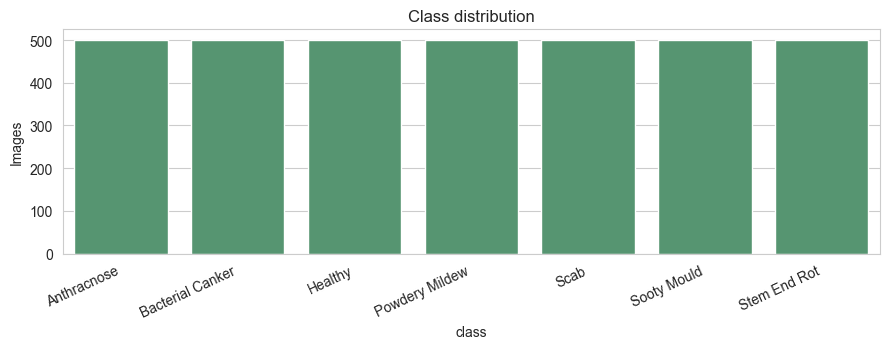

In [5]:
IMG_EXT = (".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff", ".webp")

def _norm(s): return "".join(ch for ch in s.lower() if ch.isalnum())

def find_class_root(root):
    """First folder (top-down) whose sub-folders match the expected class names.
    Other folders (e.g. an old 'Train-Test Split' copy) are ignored."""
    want = {_norm(c) for c in EXPECTED_CLASSES}
    for cur, dirs, _ in os.walk(root):
        hits = [d for d in dirs if _norm(d) in want]
        if len(hits) >= max(2, len(want) - 1):
            return cur, sorted(hits)
    return None, None

roots = [DATA_DIR] + (["/kaggle/input"] if os.path.isdir("/kaggle/input") else [])
CLASS_ROOT = CLASSES = None
for r in roots:
    if os.path.isdir(r):
        CLASS_ROOT, CLASSES = find_class_root(r)
        if CLASS_ROOT: break
assert CLASS_ROOT, f"No class folders found under {roots}. Set DATA_DIR correctly."

NUM_CLASSES = len(CLASSES)
rows = []
for ci, c in enumerate(CLASSES):
    files = sorted(f for f in os.listdir(os.path.join(CLASS_ROOT, c)) if f.lower().endswith(IMG_EXT))
    if MAX_PER_CLASS: files = files[:MAX_PER_CLASS]
    rows += [{"path": os.path.join(CLASS_ROOT, c, f), "class": c, "label": ci} for f in files]
meta = pd.DataFrame(rows)

print("Class folder :", CLASS_ROOT)
print("Classes      :", CLASSES)
dist = meta["class"].value_counts().reindex(CLASSES)
print(dist.to_string()); print("Total images :", len(meta))

plt.figure(figsize=(9, 3.6))
sns.barplot(x=dist.index, y=dist.values, color="#4C9F70")
plt.ylabel("Images"); plt.title("Class distribution"); plt.xticks(rotation=25, ha="right")
plt.tight_layout(); savefig("class_distribution"); plt.show()

## 5. Decode once and cache in RAM
Each image is opened once (EXIF orientation fixed), resized to 256×256 and saved as a `.npy` cache. Later runs load it in seconds. This removes the slow per-epoch disk reads of the previous version.

  decoded 500/3500
  decoded 1000/3500
  decoded 1500/3500
  decoded 2000/3500
  decoded 2500/3500
  decoded 3000/3500
  decoded 3500/3500
Decoded 3500 images in 88s
Cache: (3500, 256, 256, 3) 0.69 GB | unreadable: 0


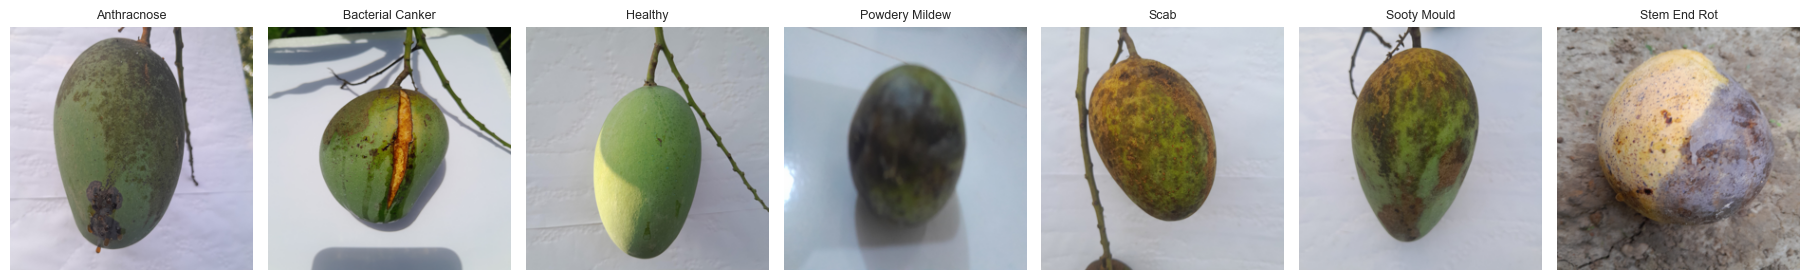

In [6]:
def load_rgb(path, size):
    with Image.open(path) as im:
        im.draft("RGB", (size * 2, size * 2))          # fast JPEG down-scaling
        im = ImageOps.exif_transpose(im).convert("RGB")
        im = im.resize((size, size), Image.BICUBIC, reducing_gap=2.0)
        return np.asarray(im, dtype=np.uint8)

key = hashlib.md5(("|".join(meta["path"]) + str(CACHE_SIZE)).encode()).hexdigest()[:10]
cache_file = os.path.join(RESULTS_DIR, f"image_cache_{key}.npy")
bad_file   = cache_file.replace(".npy", "_bad.json")

if os.path.exists(cache_file) and os.path.exists(bad_file):
    IMAGES = np.load(cache_file)
    bad = json.load(open(bad_file))
    print("Loaded image cache:", cache_file)
else:
    t0, imgs, bad = time.time(), [], []
    for i, p in enumerate(meta["path"]):
        try:
            imgs.append(load_rgb(p, CACHE_SIZE))
        except Exception as e:
            bad.append(i); print("[skip unreadable]", p, e)
        if (i + 1) % 500 == 0: print(f"  decoded {i+1}/{len(meta)}")
    IMAGES = np.stack(imgs)
    np.save(cache_file, IMAGES); json.dump(bad, open(bad_file, "w"))
    print(f"Decoded {len(IMAGES)} images in {time.time()-t0:.0f}s")

if bad:
    meta = meta.drop(index=bad).reset_index(drop=True)
LABELS = meta["label"].to_numpy()
N = len(meta)
assert len(IMAGES) == N
print("Cache:", IMAGES.shape, f"{IMAGES.nbytes/1e9:.2f} GB", "| unreadable:", len(bad))

fig, axes = plt.subplots(1, NUM_CLASSES, figsize=(2.6 * NUM_CLASSES, 2.8))
for ax, ci in zip(np.atleast_1d(axes), range(NUM_CLASSES)):
    ax.imshow(IMAGES[np.where(LABELS == ci)[0][0]]); ax.set_title(CLASSES[ci], fontsize=9); ax.axis("off")
plt.tight_layout(); savefig("sample_per_class"); plt.show()

## 6. Leakage control — near-duplicate / pre-augmented image grouping
Some public mango sets were balanced to exactly 500 images per class by **augmenting** the originals, so they contain rotated or flipped copies. A plain random split then leaks copies of a training image into the test set and inflates accuracy.

The cell below embeds every image with an ImageNet MobileNetV2, averaged over 6 flips/rotations so the embedding is orientation-invariant. It then links pairs with cosine similarity ≥ `DUP_SIM_THRESHOLD`, and every connected group always stays on **one** side of each split.
**Check the "most similar pairs" figure.** If those pairs are truly copies, grouping was needed. If they are different fruits, raise the threshold.

Method: cnn | threshold used: 0.95
Images: 3500 -> independent groups: 2405 | images that have a near-duplicate: 1592 | largest group: 15


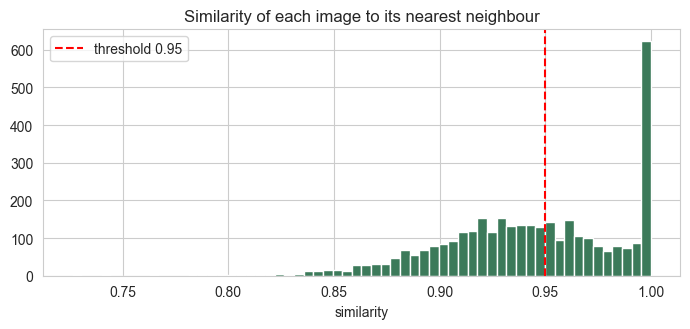

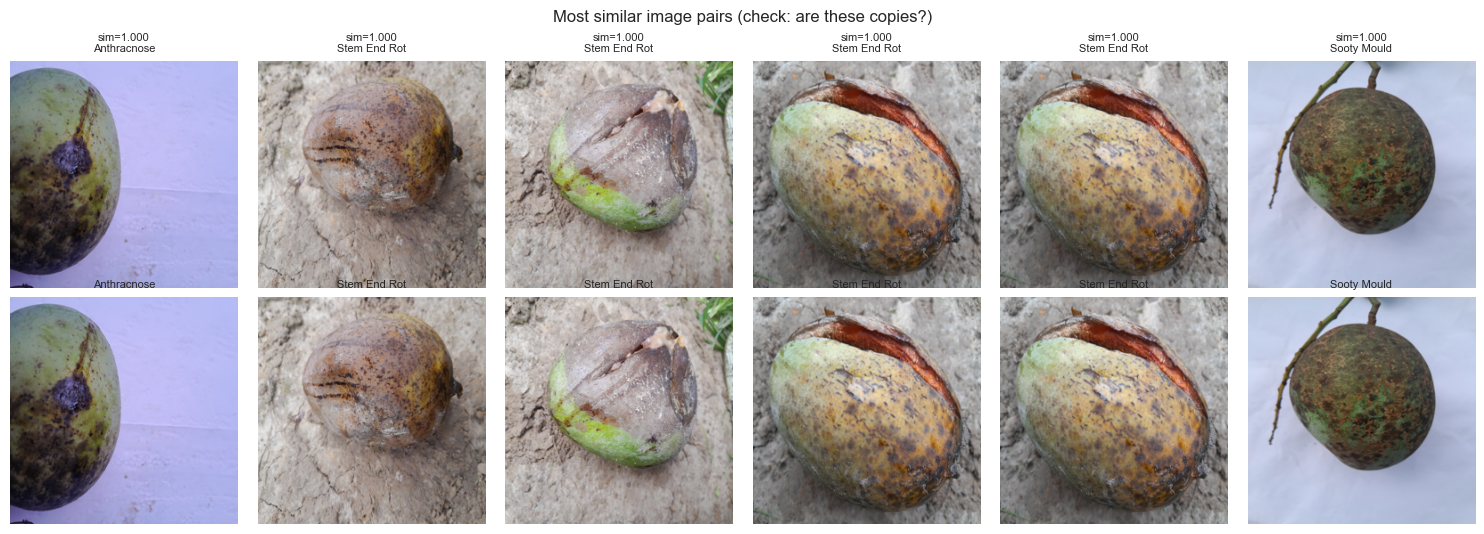

In [7]:
def try_pretrained(name):
    try:
        return timm.create_model(name, pretrained=True, num_classes=0)
    except Exception as e:
        if not ALLOW_RANDOM_INIT:
            raise RuntimeError(f"Could not download pretrained '{name}': {e}\n"
                               "Turn the internet on, or set ALLOW_RANDOM_INIT=True for a pipeline test.")
        return None

@torch.no_grad()
def cnn_embeddings(arr):
    m = try_pretrained("mobilenetv2_100")
    if m is None: return None
    m = m.to(DEVICE).eval()
    mean = torch.tensor([0.485, 0.456, 0.406], device=DEVICE).view(1, 3, 1, 1)
    std  = torch.tensor([0.229, 0.224, 0.225], device=DEVICE).view(1, 3, 1, 1)
    out = []
    for i in range(0, len(arr), 64):
        x = torch.from_numpy(arr[i:i+64]).to(DEVICE).permute(0, 3, 1, 2).float().div(255)
        x = F.interpolate(x, size=(IMG_SIZE, IMG_SIZE), mode="bilinear", align_corners=False)
        x = (x - mean) / std
        views = [x, x.flip(3), x.flip(2), x.rot90(1, (2, 3)), x.rot90(2, (2, 3)), x.rot90(3, (2, 3))]
        f = sum(F.normalize(m(v).float(), dim=1) for v in views)
        out.append(F.normalize(f, dim=1).cpu())
    del m; cleanup()
    return torch.cat(out).numpy()

def dhash_similarity(arr):
    """Fallback (no pretrained weights): 64-bit difference hash, min over flips/rotations."""
    def bits(a):
        g = np.asarray(Image.fromarray(np.ascontiguousarray(a)).convert("L").resize((9, 8), Image.BILINEAR), np.int16)
        return (g[:, 1:] > g[:, :-1]).flatten()
    base = np.stack([bits(a) for a in arr]).astype(np.float32)
    best = np.zeros((len(arr), len(arr)), np.float32)
    for tf in (lambda a: a, lambda a: a[:, ::-1], lambda a: a[::-1],
               lambda a: np.rot90(a, 1), lambda a: np.rot90(a, 2), lambda a: np.rot90(a, 3)):
        v = np.stack([bits(tf(a)) for a in arr]).astype(np.float32)
        ham = v @ (1 - base).T + (1 - v) @ base.T
        best = np.maximum(best, 1 - ham / 64.0)
    return np.maximum(best, best.T)

if DEDUP:
    E = cnn_embeddings(IMAGES)
    if E is not None:
        S, method, thr = E @ E.T, "cnn", DUP_SIM_THRESHOLD
    else:
        S, method, thr = dhash_similarity(IMAGES), "dhash", 0.90
    np.fill_diagonal(S, -1.0)
    while True:
        n_groups, GROUPS = connected_components(csr_matrix(S >= thr), directed=False)
        largest = np.bincount(GROUPS).max()
        if largest <= MAX_GROUP_SIZE or thr >= 0.999: break
        thr = round(thr + 0.005, 4)
    nn_sim = S.max(1)
    sizes = np.bincount(GROUPS)
    print(f"Method: {method} | threshold used: {thr}")
    print(f"Images: {N} -> independent groups: {n_groups} | images that have a near-duplicate: "
          f"{int((sizes[GROUPS] > 1).sum())} | largest group: {largest}")

    plt.figure(figsize=(7, 3.4))
    plt.hist(nn_sim, bins=60, color="#3C7A5A"); plt.axvline(thr, color="r", ls="--", label=f"threshold {thr}")
    plt.title("Similarity of each image to its nearest neighbour"); plt.xlabel("similarity"); plt.legend()
    plt.tight_layout(); savefig("duplicate_similarity_hist"); plt.show()

    iu = np.triu_indices(N, 1); top = np.argsort(-S[iu])[:6]
    fig, axes = plt.subplots(2, len(top), figsize=(2.5 * len(top), 5.4), squeeze=False)
    for k, t in enumerate(top):
        i, j = iu[0][t], iu[1][t]
        axes[0, k].imshow(IMAGES[i]); axes[1, k].imshow(IMAGES[j])
        axes[0, k].set_title(f"sim={S[i, j]:.3f}\n{CLASSES[LABELS[i]]}", fontsize=8)
        axes[1, k].set_title(CLASSES[LABELS[j]], fontsize=8)
        axes[0, k].axis("off"); axes[1, k].axis("off")
    plt.suptitle("Most similar image pairs (check: are these copies?)")
    plt.tight_layout(); savefig("most_similar_pairs"); plt.show()
    del S
else:
    GROUPS, method, thr = np.arange(N), "none", None

meta["group"] = GROUPS
meta.to_csv(os.path.join(RESULTS_DIR, "dataset_index_with_groups.csv"), index=False)

## 7. Repeated stratified-group K-fold splits
Every model is trained and tested on **exactly the same** splits. Inside each training fold a group-aware validation set is used for early stopping only.

In [8]:
SPLITS = []
for r in range(N_REPEATS):
    outer = StratifiedGroupKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED + r)
    for f, (trv, te) in enumerate(outer.split(np.zeros(N), LABELS, GROUPS)):
        inner = StratifiedGroupKFold(n_splits=INNER_VAL_SPLITS, shuffle=True, random_state=SEED + 100 * r + f)
        tr_i, va_i = next(inner.split(np.zeros(len(trv)), LABELS[trv], GROUPS[trv]))
        tr, va = np.sort(trv[tr_i]), np.sort(trv[va_i])
        g_tr, g_va, g_te = set(GROUPS[tr]), set(GROUPS[va]), set(GROUPS[te])
        assert not (g_tr & g_te) and not (g_va & g_te) and not (g_tr & g_va), "group leakage!"
        SPLITS.append({"r": r, "f": f, "train": tr, "val": va, "test": np.sort(te)})

print(f"{len(SPLITS)} folds ({N_REPEATS} repeats x {N_FOLDS}); no group appears on two sides.")
print(pd.DataFrame([{"repeat": s["r"] + 1, "fold": s["f"] + 1, "train": len(s["train"]),
                     "val": len(s["val"]), "test": len(s["test"])} for s in SPLITS]).to_string(index=False))
# every image is tested exactly once per repeat
for r in range(N_REPEATS):
    cover = np.concatenate([s["test"] for s in SPLITS if s["r"] == r])
    assert len(cover) == N and len(np.unique(cover)) == N
json.dump([{k: (v.tolist() if isinstance(v, np.ndarray) else v) for k, v in s.items()} for s in SPLITS],
          open(os.path.join(RESULTS_DIR, "splits.json"), "w"))

10 folds (2 repeats x 5); no group appears on two sides.
 repeat  fold  train  val  test
      1     1   2360  447   693
      1     2   2327  461   712
      1     3   2347  459   694
      1     4   2345  477   678
      1     5   2309  468   723
      2     1   2291  494   715
      2     2   2355  461   684
      2     3   2323  480   697
      2     4   2328  461   711
      2     5   2330  477   693


## 8. GPU data pipeline and augmentation
The whole uint8 image cache (~0.7 GB) sits **on the GPU**, and augmentation runs there per sample in one `grid_sample` call per batch. That means there are no DataLoader workers (which break in Windows Jupyter) and no CPU bottleneck.
Augmentation is the same for every model: random-resized crop (area 0.70–1.0, aspect 0.8–1.25), horizontal/vertical flips, ±15° rotation (p = 0.5), and brightness/contrast ±10 %. There is **no hue/saturation change**, because colour is diagnostic (brown corky scab vs. black sooty film). Each backbone normalises with its own pretrained mean/std inside the model.

Image tensor (3500, 3, 256, 256) (0.69 GB) on cuda:0


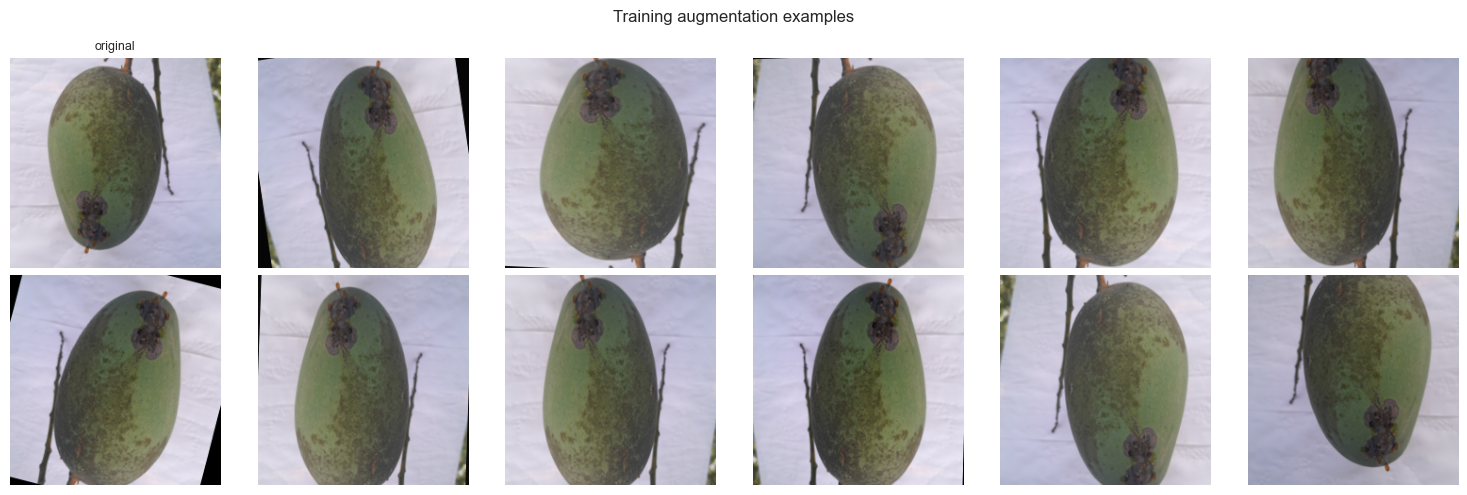

In [9]:
IMG_T = torch.from_numpy(IMAGES).permute(0, 3, 1, 2).contiguous()          # N,3,S,S uint8
if DEVICE == "cuda" and IMG_T.numel() < 0.25 * torch.cuda.get_device_properties(0).total_memory:
    IMG_T = IMG_T.to(DEVICE)
DATA_DEV = IMG_T.device
print(f"Image tensor {tuple(IMG_T.shape)} ({IMG_T.numel()/1e9:.2f} GB) on {DATA_DEV}")

def load_batch(idx):
    return IMG_T[torch.as_tensor(np.asarray(idx), dtype=torch.long, device=DATA_DEV)].to(DEVICE, non_blocking=True)

def eval_preprocess(xb):
    x = xb.float().div_(255)
    return F.interpolate(x, size=(IMG_SIZE, IMG_SIZE), mode="bilinear", align_corners=False, antialias=True)

def train_augment(xb, gen):
    B, dev = xb.shape[0], xb.device
    x = xb.float().div_(255)
    U = lambda lo, hi: lo + (hi - lo) * torch.rand(B, generator=gen, device=dev)
    coin = lambda p: (torch.rand(B, generator=gen, device=dev) < p).float()
    area, ratio = U(0.70, 1.0), torch.exp(U(math.log(0.8), math.log(1.25)))
    sw = torch.sqrt(area * ratio).clamp(max=1.0); sh = torch.sqrt(area / ratio).clamp(max=1.0)
    cx, cy = U(-1, 1) * (1 - sw), U(-1, 1) * (1 - sh)                    # crop centre
    fx, fy = 1 - 2 * coin(0.5), 1 - 2 * coin(0.5)                       # h / v flip
    ang = torch.deg2rad(U(-15, 15)) * coin(0.5)                          # rotation
    cos, sin = torch.cos(ang), torch.sin(ang)
    theta = torch.zeros(B, 2, 3, device=dev)
    theta[:, 0, 0], theta[:, 0, 1], theta[:, 0, 2] = sw * fx * cos, sw * fx * sin, cx
    theta[:, 1, 0], theta[:, 1, 1], theta[:, 1, 2] = -sh * fy * sin, sh * fy * cos, cy
    grid = F.affine_grid(theta, [B, 3, IMG_SIZE, IMG_SIZE], align_corners=False)
    x = F.grid_sample(x, grid, mode="bilinear", padding_mode="zeros", align_corners=False)
    x = x * U(0.9, 1.1).view(B, 1, 1, 1)                                 # brightness
    gray = (0.299 * x[:, 0] + 0.587 * x[:, 1] + 0.114 * x[:, 2]).mean((1, 2)).view(B, 1, 1, 1)
    return ((x - gray) * U(0.9, 1.1).view(B, 1, 1, 1) + gray).clamp_(0, 1)   # contrast

def batches(idx, bs, shuffle=False, gen=None, drop_last=False):
    idx = np.asarray(idx)
    if shuffle: idx = idx[torch.randperm(len(idx), generator=gen).numpy()]
    stop = len(idx) - (len(idx) % bs) if (drop_last and len(idx) >= bs) else len(idx)
    for i in range(0, stop, bs):
        yield idx[i:i + bs]

g = torch.Generator(device=DEVICE); g.manual_seed(SEED)
demo = train_augment(load_batch([0] * 11), g).cpu()
fig, axes = plt.subplots(2, 6, figsize=(15, 5))
axes[0, 0].imshow(eval_preprocess(load_batch([0]))[0].permute(1, 2, 0).cpu()); axes[0, 0].set_title("original", fontsize=9)
for ax, im in zip(axes.ravel()[1:], demo): ax.imshow(im.permute(1, 2, 0))
for ax in axes.ravel(): ax.axis("off")
plt.suptitle("Training augmentation examples"); plt.tight_layout(); savefig("augmentation_examples"); plt.show()

## 9. Models
`Normalized` wraps every network so each backbone gets its own pretrained normalisation and the list of *new* parameters (which receive `LR × NEW_LR_MULT`). The same rule is applied to every model.

In [10]:
class Normalized(nn.Module):
    def __init__(self, net, mean, std, new_param_names):
        super().__init__()
        self.net = net
        self.register_buffer("mean", torch.tensor(mean, dtype=torch.float32).view(1, 3, 1, 1))
        self.register_buffer("std",  torch.tensor(std,  dtype=torch.float32).view(1, 3, 1, 1))
        self.new_param_names = set("net." + n for n in new_param_names)
    def forward(self, x):
        return self.net((x - self.mean) / self.std)

def count_params(m):
    return sum(p.numel() for p in m.parameters()) / 1e6

def create_timm(candidates, pretrained, **kw):
    last = None
    for name in candidates:
        try:
            return timm.create_model(name, pretrained=pretrained, **kw), name
        except Exception as e:
            last = e
    if pretrained and ALLOW_RANDOM_INIT:
        print(f"[warn] pretrained weights unavailable for {candidates} -> random init (pipeline test only)")
        return timm.create_model(candidates[0], pretrained=False, **kw), candidates[0]
    raise RuntimeError(f"Could not create {candidates} (pretrained={pretrained}): {last}")

def build_baseline(display_name, pretrained=None):
    pretrained = PRETRAINED if pretrained is None else pretrained
    net, _ = create_timm(BASELINES[display_name], pretrained,
                         num_classes=NUM_CLASSES, drop_rate=DROP_RATE)
    clf = net.get_classifier()
    clf_names = [n for n, p in net.named_parameters() if any(p is q for q in clf.parameters())]
    cfg = net.pretrained_cfg
    return Normalized(net, cfg.get("mean", (0.485, 0.456, 0.406)), cfg.get("std", (0.229, 0.224, 0.225)), clf_names)


# ------------------------- proposed: MAF-Net -------------------------
class ConvBNAct(nn.Sequential):
    def __init__(self, cin, cout, k=1, s=1, groups=1):
        super().__init__(nn.Conv2d(cin, cout, k, s, k // 2, groups=groups, bias=False),
                         nn.BatchNorm2d(cout), nn.SiLU(inplace=True))

class CoordAtt(nn.Module):
    """Coordinate Attention (Hou et al., CVPR 2021)."""
    def __init__(self, ch, reduction=32):
        super().__init__()
        mid = max(8, ch // reduction)
        self.conv1 = nn.Conv2d(ch, mid, 1, bias=False)
        self.bn1 = nn.BatchNorm2d(mid)
        self.act = nn.Hardswish()
        self.conv_h = nn.Conv2d(mid, ch, 1)
        self.conv_w = nn.Conv2d(mid, ch, 1)
    def forward(self, x):
        h, w = x.shape[-2:]
        xh = x.mean(dim=3, keepdim=True)                       # B,C,H,1
        xw = x.mean(dim=2, keepdim=True).transpose(2, 3)       # B,C,W,1
        y = self.act(self.bn1(self.conv1(torch.cat([xh, xw], dim=2))))
        yh, yw = torch.split(y, [h, w], dim=2)
        a_h = torch.sigmoid(self.conv_h(yh))                    # B,C,H,1
        a_w = torch.sigmoid(self.conv_w(yw.transpose(2, 3)))    # B,C,1,W
        return x * a_h * a_w

class MultiScaleFusion(nn.Module):
    """Fuses stride-8 / 16 / 32 maps at stride 16 with fast-normalised learnable weights."""
    def __init__(self, in_chs, d):
        super().__init__()
        self.lat = nn.ModuleList([ConvBNAct(c, d, 1) for c in in_chs])
        self.down = ConvBNAct(d, d, 3, 2, groups=d)           # stride 8 -> 16 (depthwise)
        self.w = nn.Parameter(torch.ones(len(in_chs)))
        self.refine = nn.Sequential(ConvBNAct(d, d, 3, 1, groups=d), ConvBNAct(d, d, 1))
    def forward(self, f8, f16, f32):
        size = f16.shape[-2:]
        p8 = self.down(self.lat[0](f8))
        if p8.shape[-2:] != size:
            p8 = F.interpolate(p8, size=size, mode="nearest")
        p16 = self.lat[1](f16)
        p32 = F.interpolate(self.lat[2](f32), size=size, mode="nearest")
        w = F.relu(self.w); w = w / (w.sum() + 1e-4)
        return self.refine(w[0] * p8 + w[1] * p16 + w[2] * p32)

class MAFNet(nn.Module):
    def __init__(self, num_classes, use_msf=True, use_ca=True, pretrained=True):
        super().__init__()
        self.backbone, _ = create_timm(["mobilenetv2_100"], pretrained, num_classes=0, global_pool="")
        self.use_msf, self.use_ca = use_msf, use_ca
        top = self.backbone.num_features                       # 1280
        self.tap = (2, 4)                                      # blocks -> stride 8 (32 ch), stride 16 (96 ch)
        chs = [self.backbone.blocks[i][-1].conv_pwl.out_channels for i in self.tap]
        if use_msf:
            self.msf = MultiScaleFusion(chs + [top], FUSION_DIM)
        self.ca = CoordAtt(FUSION_DIM if use_msf else top, CA_REDUCTION) if use_ca else nn.Identity()
        self.drop = nn.Dropout(DROP_RATE)
        self.head = nn.Linear(top + (FUSION_DIM if use_msf else 0), num_classes)

    def features(self, x):
        b = self.backbone
        x = b.bn1(b.conv_stem(x)); taps = []
        for i, blk in enumerate(b.blocks):
            x = blk(x)
            if i in self.tap: taps.append(x)
        return taps[0], taps[1], b.bn2(b.conv_head(x))

    def forward(self, x):
        f8, f16, f32 = self.features(x)
        if self.use_msf:
            fused = self.ca(self.msf(f8, f16, f32))
            z = torch.cat([f32.mean((2, 3)), fused.mean((2, 3))], dim=1)
        else:
            z = self.ca(f32).mean((2, 3))
        return self.head(self.drop(z))

def build_mafnet(use_msf=True, use_ca=True, pretrained=None):
    pretrained = PRETRAINED if pretrained is None else pretrained
    net = MAFNet(NUM_CLASSES, use_msf, use_ca, pretrained)
    new = [n for n, _ in net.named_parameters() if not n.startswith("backbone.")]
    return Normalized(net, (0.485, 0.456, 0.406), (0.229, 0.224, 0.225), new)

# Ablation / proposed variants (KD = training-time only, no architecture change)
VARIANTS = {
    "MobileNetV2 + MSF":      dict(msf=True,  ca=False, kd=False),
    "MobileNetV2 + MSF + CA": dict(msf=True,  ca=True,  kd=False),
    "MobileNetV2 + KD":       dict(msf=False, ca=False, kd=True),
    "MAF-Net w/o MSF":        dict(msf=False, ca=True,  kd=True),
    "MAF-Net w/o CA":         dict(msf=True,  ca=False, kd=True),
    PROPOSED:                 dict(msf=True,  ca=True,  kd=True),
}
if not RUN_ABLATION:
    VARIANTS = {PROPOSED: VARIANTS[PROPOSED]}

def builder_for(name, pretrained=None):
    if name in BASELINES:
        return lambda: build_baseline(name, pretrained)
    v = VARIANTS[name]
    return lambda: build_mafnet(v["msf"], v["ca"], pretrained)

_m = build_mafnet(pretrained=False)
with torch.no_grad():
    assert _m(torch.rand(2, 3, IMG_SIZE, IMG_SIZE)).shape == (2, NUM_CLASSES)
print(f"{PROPOSED}: {count_params(_m):.3f} M parameters "
      f"(new layers: {sum(p.numel() for n, p in _m.named_parameters() if n in _m.new_param_names)/1e6:.3f} M)")
del _m

MAF-Net (Proposed): 2.438 M parameters (new layers: 0.214 M)


## 10. Efficiency profiling (params, GMACs, CPU / GPU latency at batch 1)

In [11]:
@torch.no_grad()
def profile(model):
    model = model.eval().float().cpu()
    x = torch.rand(1, 3, IMG_SIZE, IMG_SIZE)
    try:
        from torch.utils.flop_counter import FlopCounterMode
        with FlopCounterMode(display=False) as fc:
            model(x)
        gmacs = fc.get_total_flops() / 2e9
    except Exception:
        gmacs = float("nan")
    old = torch.get_num_threads(); torch.set_num_threads(CPU_THREADS)
    for _ in range(3): model(x)
    t = []
    for _ in range(LAT_RUNS_CPU):
        t0 = time.perf_counter(); model(x); t.append((time.perf_counter() - t0) * 1e3)
    torch.set_num_threads(old)
    cpu_ms = float(np.median(t))
    gpu_ms = float("nan")
    if DEVICE == "cuda":
        model = model.cuda(); xg = x.cuda()
        for _ in range(10): model(xg)
        torch.cuda.synchronize(); t = []
        for _ in range(LAT_RUNS_GPU):
            t0 = time.perf_counter(); model(xg); torch.cuda.synchronize(); t.append((time.perf_counter() - t0) * 1e3)
        gpu_ms = float(np.median(t))
    return {"params_M": count_params(model), "GMACs": gmacs, "size_MB": count_params(model) * 4,
            "cpu_ms": cpu_ms, "gpu_ms": gpu_ms}

eff_file = os.path.join(TAB_DIR, "efficiency.csv")
if os.path.exists(eff_file):
    EFF = pd.read_csv(eff_file, index_col=0)
    print("Loaded", eff_file)
else:
    eff = {}
    for name in list(BASELINES) + list(VARIANTS):
        m = builder_for(name, pretrained=False)()     # architecture only; weights do not change cost
        eff[name] = profile(m); del m; cleanup()
        print(f"{name:26s} {eff[name]['params_M']:7.2f} M  {eff[name]['GMACs']:6.2f} GMACs  "
              f"CPU {eff[name]['cpu_ms']:7.1f} ms  GPU {eff[name]['gpu_ms']:6.2f} ms")
    EFF = pd.DataFrame(eff).T
    EFF.to_csv(eff_file)
EFF.round(3)

VGG16                       134.29 M   15.47 GMACs  CPU   156.6 ms  GPU   4.49 ms
ResNet50                     23.52 M    4.09 GMACs  CPU    41.6 ms  GPU   5.45 ms
DenseNet121                   6.96 M    2.83 GMACs  CPU    41.2 ms  GPU  13.58 ms
InceptionV3                  21.80 M    2.84 GMACs  CPU    47.1 ms  GPU  10.74 ms
Xception                     20.82 M    4.55 GMACs  CPU    56.8 ms  GPU   5.13 ms
EfficientNet-B0               4.02 M    0.38 GMACs  CPU    14.1 ms  GPU   7.09 ms
MobileNetV2                   2.23 M    0.30 GMACs  CPU    10.8 ms  GPU   5.33 ms
MobileNetV3-L                 4.21 M    0.22 GMACs  CPU    10.5 ms  GPU   5.76 ms
DeiT-Tiny                     5.53 M    1.07 GMACs  CPU    14.5 ms  GPU   5.21 ms
MobileViT-S                   4.94 M    1.42 GMACs  CPU    29.3 ms  GPU  10.18 ms
MobileNetV2 + MSF             2.43 M    0.32 GMACs  CPU    10.1 ms  GPU  13.66 ms
MobileNetV2 + MSF + CA        2.44 M    0.32 GMACs  CPU    10.2 ms  GPU   5.86 ms
MobileNetV2 + KD

,params_M,GMACs,size_MB,cpu_ms,gpu_ms
VGG16,134.289,15.466,537.157,156.623,4.485
ResNet50,23.522,4.087,94.090,41.640,5.446
DenseNet121,6.961,2.833,27.844,41.214,13.577
InceptionV3,21.800,2.836,87.200,47.058,10.740
Xception,20.821,4.551,83.285,56.784,5.128
EfficientNet-B0,4.017,0.385,16.066,14.129,7.093
MobileNetV2,2.233,0.300,8.931,10.777,5.334
MobileNetV3-L,4.211,0.215,16.844,10.527,5.756
DeiT-Tiny,5.526,1.075,22.103,14.520,5.207
MobileViT-S,4.942,1.416,19.768,29.263,10.181


## 11. Training engine (identical for every model)
AdamW, linear warm-up and cosine decay, label smoothing 0.1, bf16 autocast on the RTX 5070, gradient clipping, and early stopping on validation loss. The best-validation checkpoint is restored. Test folds are never seen during training or model selection.
For KD variants the loss is `(1-α)·CE + α·T²·KL(teacher‖student)`. The teacher logits come from the heavy baselines trained on the **same training fold** (clean + h-flip views), so no test information leaks into them.

In [12]:
def make_optimizer(model):
    groups = {}
    for n, p in model.named_parameters():
        if not p.requires_grad: continue
        new = n in model.new_param_names
        decay = p.ndim > 1 and not any(k in n for k in ("pos_embed", "cls_token", "dist_token"))
        groups.setdefault((new, decay), []).append(p)
    pg = [{"params": ps, "lr": LR * (NEW_LR_MULT if new else 1.0),
           "weight_decay": WEIGHT_DECAY if decay else 0.0} for (new, decay), ps in groups.items()]
    return torch.optim.AdamW(pg)

def make_scheduler(opt, steps_per_epoch):
    total = EPOCHS * steps_per_epoch; warm = max(1, WARMUP_EPOCHS * steps_per_epoch)
    def f(step):
        if step < warm: return (step + 1) / warm
        prog = (step - warm) / max(1, total - warm)
        return 0.01 + 0.99 * 0.5 * (1 + math.cos(math.pi * min(1.0, prog)))
    return torch.optim.lr_scheduler.LambdaLR(opt, f)

def kd_loss(student, teacher, T):
    return F.kl_div(F.log_softmax(student / T, 1), F.softmax(teacher / T, 1), reduction="batchmean") * T * T

def to_dev(x):
    x = x.to(DEVICE, non_blocking=True)
    return x.contiguous(memory_format=torch.channels_last) if DEVICE == "cuda" else x

@torch.no_grad()
def predict_logits(model, idx, hflip=False):
    model.eval(); outs = []
    for b in batches(idx, BATCH_SIZE * 2):
        x = to_dev(eval_preprocess(load_batch(b)))
        if hflip: x = x.flip(3)
        with torch.autocast(device_type="cuda" if DEVICE == "cuda" else "cpu", dtype=AMP_DTYPE, enabled=USE_AMP):
            o = model(x)
        outs.append(o.float().cpu())
    return torch.cat(outs).numpy()

def train_model(model, split, seed, teacher_logits=None, tag=""):
    model = model.to(DEVICE)
    if DEVICE == "cuda": model = model.to(memory_format=torch.channels_last)
    g_cpu = torch.Generator(); g_cpu.manual_seed(seed)
    g_dev = torch.Generator(device=DEVICE); g_dev.manual_seed(seed)
    tr_idx = split["train"]
    steps = max(1, len(tr_idx) // BATCH_SIZE)
    va_idx, va_y = split["val"], torch.as_tensor(LABELS[split["val"]])
    opt = make_optimizer(model); sched = make_scheduler(opt, steps)
    scaler = torch.amp.GradScaler("cuda", enabled=(USE_AMP and AMP_DTYPE == torch.float16))
    T_all = torch.from_numpy(teacher_logits).float().to(DEVICE) if teacher_logits is not None else None

    hist = {"tr_loss": [], "tr_acc": [], "va_loss": [], "va_acc": []}
    best_loss, best_state, best_ep = float("inf"), None, -1
    for ep in range(EPOCHS):
        model.train(); tl_sum = tc = n = 0
        for b in batches(tr_idx, BATCH_SIZE, shuffle=True, gen=g_cpu, drop_last=True):
            x = to_dev(train_augment(load_batch(b), g_dev))
            y = torch.as_tensor(LABELS[b], device=DEVICE)
            with torch.autocast(device_type="cuda" if DEVICE == "cuda" else "cpu", dtype=AMP_DTYPE, enabled=USE_AMP):
                out = model(x)
            out = out.float()
            loss = F.cross_entropy(out, y, label_smoothing=LABEL_SMOOTHING)
            if T_all is not None:
                loss = (1 - KD_ALPHA) * loss + KD_ALPHA * kd_loss(out, T_all[torch.as_tensor(b, device=DEVICE)], KD_TEMPERATURE)
            if not torch.isfinite(loss):
                raise FloatingPointError(f"[{tag}] non-finite loss at epoch {ep+1}")
            opt.zero_grad(set_to_none=True)
            scaler.scale(loss).backward()
            scaler.unscale_(opt)
            nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
            scaler.step(opt); scaler.update(); sched.step()
            tl_sum += loss.item() * len(y); tc += (out.argmax(1) == y).sum().item(); n += len(y)
        vlog = torch.from_numpy(predict_logits(model, va_idx))
        v_loss = F.cross_entropy(vlog, va_y).item(); v_acc = (vlog.argmax(1) == va_y).float().mean().item()
        for k, v in zip(hist, (tl_sum / n, tc / n, v_loss, v_acc)): hist[k].append(v)
        if v_loss < best_loss - 1e-4:
            best_loss, best_ep = v_loss, ep
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        elif ep - best_ep >= PATIENCE:
            break
    model.load_state_dict(best_state)
    return model, hist, best_ep + 1

## 12. Run all experiments (resume-safe)
Order inside every fold: baselines first (the teachers are among them), then teacher-ensemble logits, then MAF-Net and its ablations. Each finished (fold, model) run is saved to `runs/`. Re-running this cell skips finished runs.

In [13]:
def safe(s): return "".join(ch if ch.isalnum() else "_" for ch in s)
def run_path(sp, name): return os.path.join(RUN_DIR, f"r{sp['r']}_f{sp['f']}_{safe(name)}.npz")

def run_one(sp, name, teacher_logits=None, keep_teacher=False):
    path = run_path(sp, name)
    if os.path.exists(path):
        return dict(np.load(path)), True
    seed = SEED + 1000 * sp["r"] + 10 * sp["f"]
    seed_everything(seed)
    model = builder_for(name)()
    t0 = time.time()
    model, hist, best_ep = train_model(model, sp, seed, teacher_logits, tag=name)
    secs = time.time() - t0
    rec = {"test_idx": sp["test"], "test_logits": predict_logits(model, sp["test"]),
           "train_idx": sp["train"], "hist": np.array(json.dumps(hist)),
           "best_epoch": np.array(best_ep), "seconds": np.array(secs)}
    if keep_teacher:   # soft targets for KD: clean + horizontal-flip view, training images only
        rec["teacher_logits"] = (predict_logits(model, sp["train"]) + predict_logits(model, sp["train"], hflip=True)) / 2
    if sp["r"] == 0 and sp["f"] == 0 and name in (PROPOSED, "MobileNetV2"):
        torch.save(model.state_dict(), os.path.join(W_DIR, f"{safe(name)}_r0_f0.pt"))
    tmp = path + ".tmp"
    with open(tmp, "wb") as fh:
        np.savez(fh, **rec)
    os.replace(tmp, path)
    del model; cleanup()
    return rec, False

RUN_ORDER = list(BASELINES) + list(VARIANTS)
total, done_n, t_start = len(SPLITS) * len(RUN_ORDER), 0, time.time()
fresh_secs = []
for sp in SPLITS:
    print(f"\n========== repeat {sp['r']+1}/{N_REPEATS}  fold {sp['f']+1}/{N_FOLDS} ==========")
    teacher = None
    for name in RUN_ORDER:
        if name in VARIANTS and VARIANTS[name]["kd"] and teacher is None:
            teacher = np.zeros((N, NUM_CLASSES), np.float32)
            for t in TEACHERS:
                rec_t = dict(np.load(run_path(sp, t)))
                teacher[rec_t["train_idx"]] += rec_t["teacher_logits"] / len(TEACHERS)
        use_t = teacher if (name in VARIANTS and VARIANTS[name]["kd"]) else None
        rec, cached = run_one(sp, name, use_t, keep_teacher=(name in TEACHERS))
        acc = (rec["test_logits"].argmax(1) == LABELS[rec["test_idx"]]).mean()
        done_n += 1
        if not cached: fresh_secs.append(float(rec["seconds"]))
        eta = (np.mean(fresh_secs) * (total - done_n) / 3600) if fresh_secs else 0
        took = "cached" if cached else "{:5.1f} min".format(float(rec["seconds"]) / 60)
        print(f"  {name:26s} acc={acc:.4f}  best_ep={int(rec['best_epoch']):2d}  {took}   "
              f"[{done_n}/{total}, ETA ~{eta:.1f} h]")
print(f"\nAll runs finished. Wall time this session: {(time.time()-t_start)/3600:.2f} h")


========== repeat 1/2  fold 1/5 ==========
  VGG16                      acc=0.9553  best_ep=17    3.5 min   [1/160, ETA ~9.1 h]
  ResNet50                   acc=0.9553  best_ep= 6    0.9 min   [2/160, ETA ~5.7 h]
  DenseNet121                acc=0.9524  best_ep= 7    1.8 min   [3/160, ETA ~5.3 h]
  InceptionV3                acc=0.9509  best_ep=11    1.6 min   [4/160, ETA ~5.0 h]
  Xception                   acc=0.9639  best_ep=10    1.5 min   [5/160, ETA ~4.8 h]
  EfficientNet-B0            acc=0.9524  best_ep=14    1.8 min   [6/160, ETA ~4.7 h]
  MobileNetV2                acc=0.9610  best_ep= 5    0.8 min   [7/160, ETA ~4.3 h]
  MobileNetV3-L              acc=0.9697  best_ep=11    1.2 min   [8/160, ETA ~4.1 h]


c:\Users\saifu\.conda\envs\pytorch\lib\site-packages\torch\autograd\graph.py:829: UserWarning: Memory Efficient attention defaults to a non-deterministic algorithm. To explicitly enable determinism call torch.use_deterministic_algorithms(True, warn_only=False). (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\native\transformers\cuda\attention_backward.cu:777.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


  DeiT-Tiny                  acc=0.9509  best_ep= 7    0.7 min   [9/160, ETA ~3.8 h]


model.safetensors:   0%|          | 0.00/22.4M [00:00<?, ?B/s]

c:\Users\saifu\.conda\envs\pytorch\lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\saifu\.cache\huggingface\hub\models--timm--mobilevit_s.cvnets_in1k. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


  MobileViT-S                acc=0.9553  best_ep= 6    1.5 min   [10/160, ETA ~3.8 h]
  MobileNetV2 + MSF          acc=0.9654  best_ep=10    1.1 min   [11/160, ETA ~3.7 h]
  MobileNetV2 + MSF + CA     acc=0.9582  best_ep= 6    0.8 min   [12/160, ETA ~3.5 h]
  MobileNetV2 + KD           acc=0.9596  best_ep= 5    0.7 min   [13/160, ETA ~3.4 h]
  MAF-Net w/o MSF            acc=0.9639  best_ep=18    1.4 min   [14/160, ETA ~3.3 h]
  MAF-Net w/o CA             acc=0.9668  best_ep=20    1.6 min   [15/160, ETA ~3.3 h]
  MAF-Net (Proposed)         acc=0.9567  best_ep= 5    0.8 min   [16/160, ETA ~3.2 h]

========== repeat 1/2  fold 2/5 ==========
  VGG16                      acc=0.9228  best_ep=14    3.0 min   [17/160, ETA ~3.4 h]
  ResNet50                   acc=0.9270  best_ep=19    1.7 min   [18/160, ETA ~3.4 h]
  DenseNet121                acc=0.9256  best_ep= 9    2.0 min   [19/160, ETA ~3.5 h]
  InceptionV3                acc=0.9326  best_ep=18    2.1 min   [20/160, ETA ~3.5 h]
  Xception

## 13. Collect results — per-fold metrics and pooled out-of-fold (OOF) predictions

In [14]:
def softmax_np(z):
    z = z - z.max(1, keepdims=True); e = np.exp(z); return e / e.sum(1, keepdims=True)

def metric_dict(y, logits):
    p = softmax_np(logits.astype(np.float64)); yhat = p.argmax(1)
    pr, rc, f1, _ = precision_recall_fscore_support(y, yhat, average="macro", zero_division=0)
    try:
        auc = roc_auc_score(y, p, multi_class="ovr", average="macro", labels=list(range(NUM_CLASSES)))
    except ValueError:
        auc = np.nan
    return {"acc": accuracy_score(y, yhat), "precision": pr, "recall": rc, "f1": f1,
            "mcc": matthews_corrcoef(y, yhat), "kappa": cohen_kappa_score(y, yhat), "auc": auc}

ALL_MODELS = RUN_ORDER
rows, OOF, HIST, EPOCHS_USED = [], {}, {}, {}
for name in ALL_MODELS:
    OOF[name] = np.zeros((N_REPEATS, N, NUM_CLASSES), np.float32)
    for sp in SPLITS:
        rec = np.load(run_path(sp, name))
        idx, lg = rec["test_idx"], rec["test_logits"]
        OOF[name][sp["r"], idx] = lg
        rows.append({"model": name, "repeat": sp["r"], "fold": sp["f"], **metric_dict(LABELS[idx], lg),
                     "minutes": float(rec["seconds"]) / 60, "best_epoch": int(rec["best_epoch"])})
        if sp["r"] == 0 and sp["f"] == 0:
            HIST[name] = json.loads(str(rec["hist"]))
FOLD = pd.DataFrame(rows)
FOLD.to_csv(os.path.join(TAB_DIR, "per_fold_metrics.csv"), index=False)

MET = ["acc", "precision", "recall", "f1", "mcc", "kappa", "auc"]
def summary_table(names):
    g = FOLD[FOLD.model.isin(names)].groupby("model")
    mean, std = g[MET].mean(), g[MET].std(ddof=1)
    out = pd.DataFrame(index=mean.index)
    for m in MET:
        out[m] = [f"{100*a:.2f} ± {100*b:.2f}" for a, b in zip(mean[m], std[m])]
    out["_acc"] = mean["acc"]; out["_f1"] = mean["f1"]
    out = out.join(EFF[["params_M", "GMACs", "cpu_ms", "gpu_ms"]].round(3))
    out["train_min/fold"] = g["minutes"].mean().round(1)
    return out.sort_values(["_acc", "_f1"], ascending=False)

MAIN_MODELS = list(BASELINES) + [PROPOSED]
MAIN = summary_table(MAIN_MODELS)
MAIN.drop(columns=["_acc", "_f1"]).to_csv(os.path.join(TAB_DIR, "main_comparison.csv"))
print("Main comparison (mean ± std over", len(SPLITS), "folds, %):")
MAIN.drop(columns=["_acc", "_f1"])

Main comparison (mean ± std over 10 folds, %):


,acc,precision,recall,f1,mcc,kappa,auc,params_M,GMACs,cpu_ms,gpu_ms,train_min/fold
model,,,,,,,,,,,,
MobileViT-S,95.10 ± 0.95,95.35 ± 0.92,95.17 ± 0.93,95.16 ± 0.93,94.31 ± 1.10,94.27 ± 1.11,99.43 ± 0.33,4.942,1.416,29.263,10.181,1.9
InceptionV3,95.06 ± 1.40,95.36 ± 1.29,95.17 ± 1.30,95.15 ± 1.35,94.27 ± 1.61,94.23 ± 1.63,99.29 ± 0.42,21.800,2.836,47.058,10.740,1.7
Xception,94.92 ± 2.10,95.28 ± 1.88,95.05 ± 2.02,95.02 ± 2.04,94.13 ± 2.41,94.07 ± 2.45,99.29 ± 0.59,20.821,4.551,56.784,5.128,1.3
MobileNetV3-L,94.90 ± 1.97,95.10 ± 1.81,94.98 ± 1.92,94.97 ± 1.92,94.07 ± 2.28,94.04 ± 2.30,99.42 ± 0.16,4.211,0.215,10.527,5.756,1.0
MAF-Net (Proposed),94.87 ± 1.63,95.13 ± 1.52,94.98 ± 1.53,94.95 ± 1.58,94.05 ± 1.87,94.01 ± 1.89,99.49 ± 0.22,2.438,0.317,10.759,5.614,1.1
DenseNet121,94.64 ± 2.05,95.01 ± 1.87,94.73 ± 1.98,94.71 ± 2.02,93.80 ± 2.34,93.74 ± 2.39,99.47 ± 0.25,6.961,2.833,41.214,13.577,2.3
VGG16,94.50 ± 1.13,94.85 ± 1.00,94.57 ± 1.10,94.55 ± 1.12,93.64 ± 1.28,93.58 ± 1.32,99.42 ± 0.41,134.289,15.466,156.623,4.485,3.2
ResNet50,94.46 ± 1.54,94.80 ± 1.31,94.61 ± 1.43,94.59 ± 1.44,93.58 ± 1.76,93.53 ± 1.80,99.36 ± 0.17,23.522,4.087,41.640,5.446,1.4
EfficientNet-B0,94.42 ± 1.43,94.74 ± 1.25,94.54 ± 1.33,94.49 ± 1.38,93.54 ± 1.63,93.48 ± 1.66,99.35 ± 0.18,4.017,0.385,14.129,7.093,1.2


## 14. Statistical significance — MAF-Net vs. every baseline
* **Corrected resampled t-test** (Nadeau & Bengio, 2003). The plain paired t-test is too optimistic for CV folds because the training sets overlap.
* **Wilcoxon signed-rank** on the fold accuracies (when there are at least 6 folds).
* **Exact McNemar** on the pooled out-of-fold predictions (every image predicted once; repeat 1 is the primary result).
* **Holm correction** across the baselines, plus a **paired bootstrap 95 % CI** of the accuracy difference.

In [15]:
n_test_avg  = np.mean([len(s["test"]) for s in SPLITS])
n_train_avg = np.mean([len(s["train"]) + len(s["val"]) for s in SPLITS])

def fold_acc(name):
    return FOLD[FOLD.model == name].sort_values(["repeat", "fold"])["acc"].to_numpy()

def corrected_ttest(a, b):
    d = a - b; k = len(d)
    if k < 2: return np.nan, np.nan
    v = d.var(ddof=1)
    if v == 0: return (0.0, 1.0) if d.mean() == 0 else (np.sign(d.mean()) * np.inf, 0.0)
    t = d.mean() / np.sqrt((1 / k + n_test_avg / n_train_avg) * v)
    return t, 2 * stats.t.sf(abs(t), k - 1)

def wilcoxon_p(a, b):
    d = a - b
    if len(d) < 6 or np.all(d == 0): return np.nan
    try: return stats.wilcoxon(a, b).pvalue
    except ValueError: return np.nan

def mcnemar_exact(pred_a, pred_b, y):
    ca, cb = pred_a == y, pred_b == y
    n01, n10 = int(np.sum(ca & ~cb)), int(np.sum(~ca & cb))
    p = 1.0 if n01 + n10 == 0 else stats.binomtest(min(n01, n10), n01 + n10, 0.5).pvalue
    return n01, n10, p

def holm(p):
    p = np.asarray(p, float); adj = np.full_like(p, np.nan)
    ok = ~np.isnan(p); m = ok.sum(); run = 0.0
    for rank, i in enumerate(np.argsort(np.where(ok, p, np.inf))[:m]):
        run = max(run, min(1.0, (m - rank) * p[i])); adj[i] = run
    return adj

def boot_ci(pred_a, pred_b, y, B=2000, seed=SEED):
    rng = np.random.default_rng(seed); d = (pred_a == y).astype(float) - (pred_b == y).astype(float)
    bs = [d[rng.integers(0, len(d), len(d))].mean() for _ in range(B)]
    return d.mean(), np.percentile(bs, 2.5), np.percentile(bs, 97.5)

pa = fold_acc(PROPOSED)
oof_pred = {m: OOF[m].argmax(2) for m in ALL_MODELS}            # [repeat, N]
sig = []
for b in BASELINES:
    pb = fold_acc(b)
    t, p_t = corrected_ttest(pa, pb)
    n01, n10, p_mc = mcnemar_exact(oof_pred[PROPOSED][0], oof_pred[b][0], LABELS)
    p_mc_all = [mcnemar_exact(oof_pred[PROPOSED][r], oof_pred[b][r], LABELS)[2] for r in range(N_REPEATS)]
    dm, lo, hi = boot_ci(oof_pred[PROPOSED][0], oof_pred[b][0], LABELS)
    sig.append({"baseline": b, "Δacc (pp)": 100 * (pa.mean() - pb.mean()), "wins/folds": f"{int((pa > pb).sum())}/{len(pa)}",
                "t (corr.)": t, "p corr-t": p_t, "p Wilcoxon": wilcoxon_p(pa, pb),
                "McNemar n01/n10": f"{n01}/{n10}", "p McNemar": p_mc,
                "p McNemar (worst repeat)": max(p_mc_all),
                "OOF Δacc 95% CI (pp)": f"{100*dm:+.2f} [{100*lo:+.2f}, {100*hi:+.2f}]"})
SIG = pd.DataFrame(sig).set_index("baseline")
for c in ["p corr-t", "p Wilcoxon", "p McNemar"]:
    SIG[c + " (Holm)"] = holm(SIG[c].to_numpy())
SIG.to_csv(os.path.join(TAB_DIR, "significance_vs_baselines.csv"))
pd.set_option("display.float_format", lambda v: f"{v:.4g}")
SIG

,Δacc (pp),wins/folds,t (corr.),p corr-t,p Wilcoxon,McNemar n01/n10,p McNemar,p McNemar (worst repeat),OOF Δacc 95% CI (pp),p corr-t (Holm),p Wilcoxon (Holm),p McNemar (Holm)
baseline,,,,,,,,,,,,
VGG16,0.3653,5/10,0.5858,0.5724,0.4838,92/57,0.005172,0.4744,"+1.00 [+0.31, +1.69]",1,1,0.05172
ResNet50,0.4042,7/10,0.9953,0.3456,0.06632,58/43,0.1633,0.2631,"+0.43 [-0.14, +1.00]",1,0.5968,1
DenseNet121,0.2296,7/10,0.4852,0.6392,0.5566,53/50,0.8439,0.8439,"+0.09 [-0.46, +0.66]",1,1,1
InceptionV3,-0.1887,4/10,-0.5335,0.6066,0.4316,54/63,0.4597,0.7877,"-0.26 [-0.86, +0.34]",1,1,1
Xception,-0.05601,4/10,-0.1314,0.8984,0.7695,40/60,0.05689,0.1881,"-0.57 [-1.11, +0.00]",1,1,0.4551
EfficientNet-B0,0.4487,9/10,0.8348,0.4254,0.08398,57/55,0.9248,0.9248,"+0.06 [-0.57, +0.63]",1,0.6719,1
MobileNetV2,0.4728,6/10,0.7679,0.4622,0.3223,41/28,0.148,0.148,"+0.37 [-0.11, +0.83]",1,1,1
MobileNetV3-L,-0.0327,4/10,-0.04979,0.9614,0.8457,64/57,0.5856,0.5856,"+0.20 [-0.40, +0.83]",1,1,1
DeiT-Tiny,0.854,10/10,3.011,0.0147,0.001953,86/53,0.006435,0.01869,"+0.94 [+0.26, +1.63]",0.147,0.01953,0.05791


Friedman chi2=21.092, p=0.0205 | Nemenyi CD (alpha=0.05) = 4.775
InceptionV3           4.7
MobileNetV3-L         4.7
MAF-Net (Proposed)   4.75
MobileViT-S          4.75
Xception             4.85
DenseNet121          5.65
VGG16                6.35
MobileNetV2           6.6
ResNet50             6.95
EfficientNet-B0      7.25
DeiT-Tiny            9.45


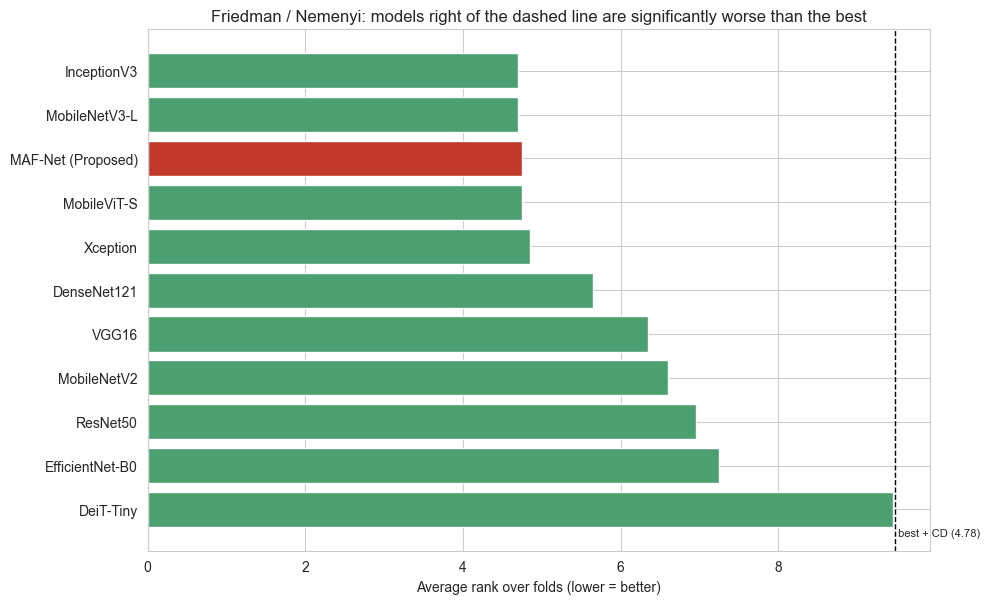

In [16]:
# ---- Friedman test + Nemenyi critical difference over all models (Demšar, 2006) ----
acc_mat = np.stack([fold_acc(m) for m in MAIN_MODELS], axis=1)          # folds x models
ranks = np.apply_along_axis(lambda r: stats.rankdata(-r), 1, acc_mat)
avg_rank = pd.Series(ranks.mean(0), index=MAIN_MODELS).sort_values()
k, n = len(MAIN_MODELS), acc_mat.shape[0]
fr_stat, fr_p = stats.friedmanchisquare(*acc_mat.T)
try:
    from scipy.stats import studentized_range
    q = studentized_range.ppf(0.95, k, 1e4) / np.sqrt(2)
except Exception:
    q = {2: 1.960, 3: 2.343, 4: 2.569, 5: 2.728, 6: 2.850, 7: 2.949, 8: 3.031, 9: 3.102,
         10: 3.164, 11: 3.219, 12: 3.268}.get(k, 3.3)
CD = q * np.sqrt(k * (k + 1) / (6 * n))
print(f"Friedman chi2={fr_stat:.3f}, p={fr_p:.3g} | Nemenyi CD (alpha=0.05) = {CD:.3f}")
print(avg_rank.round(3).to_string())

fig, ax = plt.subplots(figsize=(10, 0.45 * k + 1.2))
colors = ["#C0392B" if m == PROPOSED else "#4C9F70" for m in avg_rank.index]
ax.barh(avg_rank.index[::-1], avg_rank.values[::-1], color=colors[::-1])
best = avg_rank.iloc[0]
ax.axvline(best + CD, color="k", ls="--", lw=1)
ax.text(best + CD, -0.6, f" best + CD ({CD:.2f})", fontsize=8)
ax.set_xlabel("Average rank over folds (lower = better)")
ax.set_title("Friedman / Nemenyi: models right of the dashed line are significantly worse than the best")
plt.tight_layout(); savefig("friedman_nemenyi_cd"); plt.show()

## 15. Ablation study (same 10 folds)
Rows are cumulative (backbone → +MSF → +CA → +KD) plus leave-one-out (Full minus one component). The p-values compare each row with the full MAF-Net using the corrected resampled t-test.

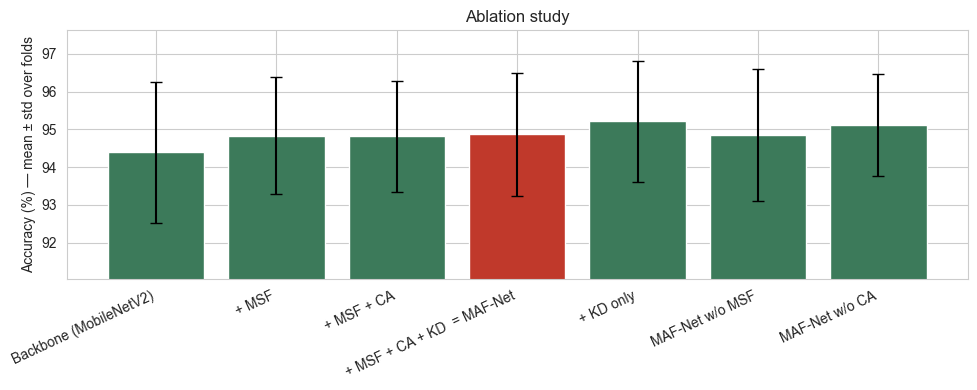

,acc (%),macro-F1 (%),Δacc vs full (pp),p vs full (corr-t),params_M,GMACs
configuration,,,,,,
Backbone (MobileNetV2),94.39 ± 1.86,94.48 ± 1.81,-0.4728,0.4622,2.233,0.2995
+ MSF,94.83 ± 1.54,94.90 ± 1.47,-0.03982,0.9331,2.434,0.3168
+ MSF + CA,94.81 ± 1.46,94.86 ± 1.43,-0.05498,0.8754,2.438,0.3169
+ MSF + CA + KD = MAF-Net,94.87 ± 1.63,94.95 ± 1.58,0,NaN,2.438,0.3169
+ KD only,95.21 ± 1.61,95.29 ± 1.57,0.3413,0.4219,2.233,0.2995
MAF-Net w/o MSF,94.85 ± 1.74,94.93 ± 1.69,-0.01835,0.9683,2.389,0.3009
MAF-Net w/o CA,95.11 ± 1.36,95.18 ± 1.32,0.2462,0.5296,2.434,0.3168


In [17]:
ABL_ROWS = [("Backbone (MobileNetV2)", "MobileNetV2"), ("+ MSF", "MobileNetV2 + MSF"),
            ("+ MSF + CA", "MobileNetV2 + MSF + CA"), ("+ MSF + CA + KD  = MAF-Net", PROPOSED),
            ("+ KD only", "MobileNetV2 + KD"), ("MAF-Net w/o MSF", "MAF-Net w/o MSF"),
            ("MAF-Net w/o CA", "MAF-Net w/o CA")]
ABL_ROWS = [(lab, m) for lab, m in ABL_ROWS if m in ALL_MODELS]
abl = []
for lab, m in ABL_ROWS:
    a = fold_acc(m); f1 = FOLD[FOLD.model == m].sort_values(["repeat", "fold"])["f1"].to_numpy()
    _, p = corrected_ttest(fold_acc(PROPOSED), a) if m != PROPOSED else (np.nan, np.nan)
    abl.append({"configuration": lab, "acc (%)": f"{100*a.mean():.2f} ± {100*a.std(ddof=1):.2f}",
                "macro-F1 (%)": f"{100*f1.mean():.2f} ± {100*f1.std(ddof=1):.2f}",
                "Δacc vs full (pp)": 100 * (a.mean() - pa.mean()), "p vs full (corr-t)": p,
                "params_M": EFF.loc[m, "params_M"], "GMACs": EFF.loc[m, "GMACs"], "_mean": a.mean(), "_std": a.std(ddof=1)})
ABL = pd.DataFrame(abl).set_index("configuration")
ABL.drop(columns=["_mean", "_std"]).to_csv(os.path.join(TAB_DIR, "ablation.csv"))

plt.figure(figsize=(10, 4))
cols = ["#C0392B" if "MAF-Net" in i and "w/o" not in i else "#3C7A5A" for i in ABL.index]
plt.bar(range(len(ABL)), 100 * ABL["_mean"], yerr=100 * ABL["_std"], color=cols, capsize=4)
plt.xticks(range(len(ABL)), ABL.index, rotation=25, ha="right")
lo = 100 * (ABL["_mean"] - ABL["_std"]).min()
plt.ylim(max(0, lo - 1.5), min(100, 100 * (ABL["_mean"] + ABL["_std"]).max() + 0.8))
plt.ylabel("Accuracy (%) — mean ± std over folds"); plt.title("Ablation study")
plt.tight_layout(); savefig("ablation"); plt.show()
ABL.drop(columns=["_mean", "_std"])

## 16. Result figures — confusion matrices, per-class F1, learning curves, accuracy-vs-cost

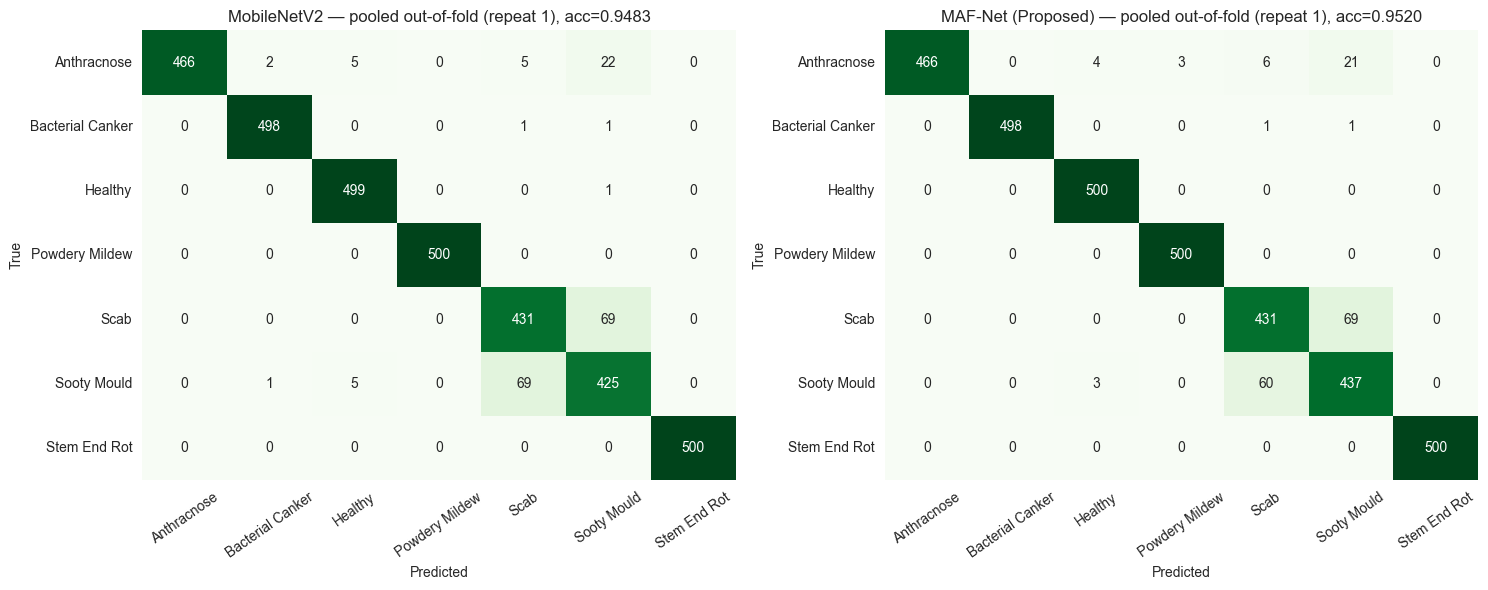

                  precision    recall  f1-score   support

     Anthracnose     1.0000    0.9320    0.9648       500
Bacterial Canker     1.0000    0.9960    0.9980       500
         Healthy     0.9862    1.0000    0.9930       500
  Powdery Mildew     0.9940    1.0000    0.9970       500
            Scab     0.8655    0.8620    0.8637       500
     Sooty Mould     0.8277    0.8740    0.8502       500
    Stem End Rot     1.0000    1.0000    1.0000       500

        accuracy                         0.9520      3500
       macro avg     0.9533    0.9520    0.9524      3500
    weighted avg     0.9533    0.9520    0.9524      3500



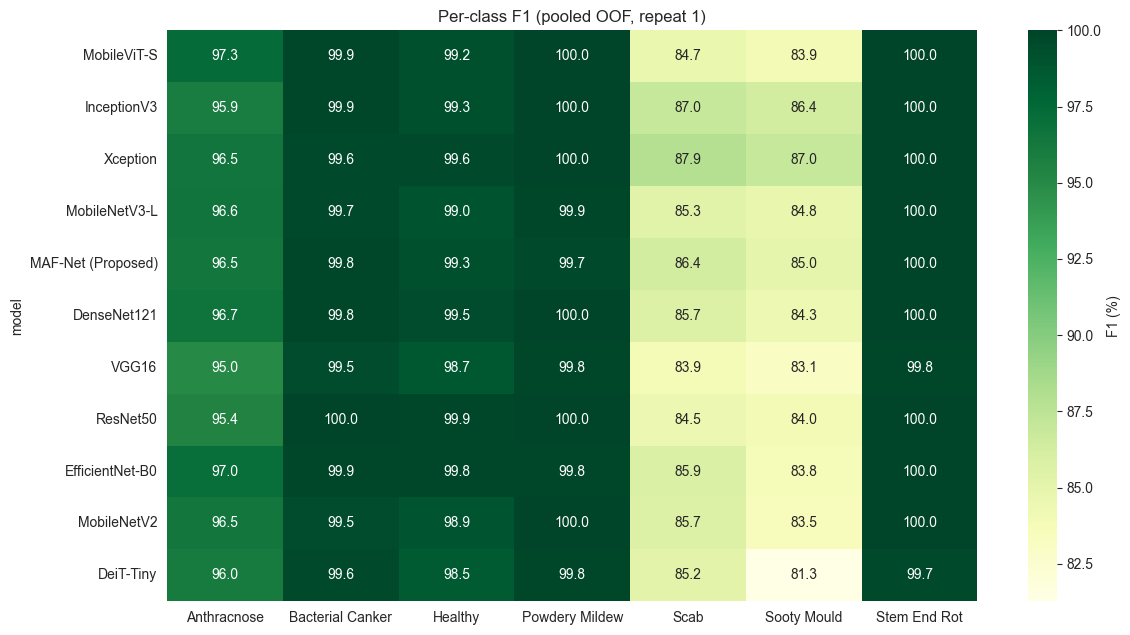

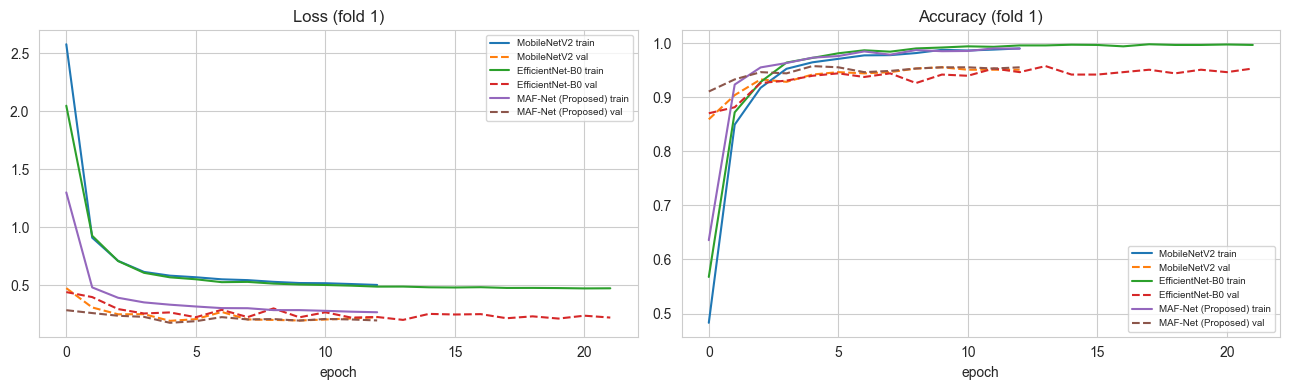

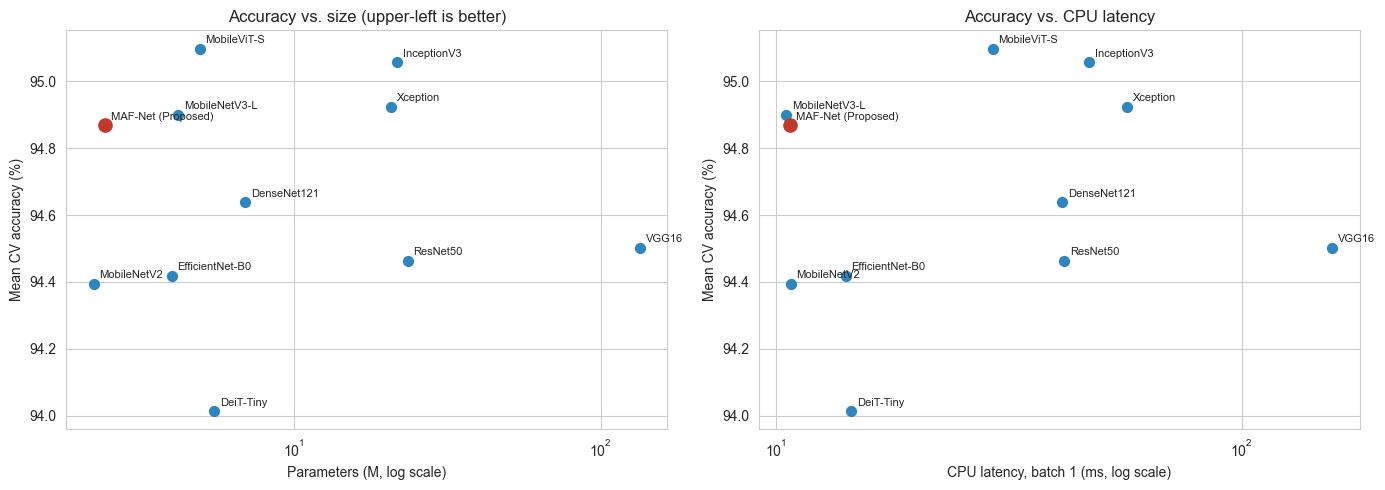

In [18]:
y0 = LABELS
fig, ax = plt.subplots(1, 2, figsize=(15, 6))
for a, m in zip(ax, ["MobileNetV2", PROPOSED]):
    cm = confusion_matrix(y0, oof_pred[m][0], labels=range(NUM_CLASSES))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Greens", xticklabels=CLASSES, yticklabels=CLASSES, ax=a, cbar=False)
    a.set_title(f"{m} — pooled out-of-fold (repeat 1), acc={np.mean(oof_pred[m][0]==y0):.4f}")
    a.set_xlabel("Predicted"); a.set_ylabel("True")
    a.tick_params(axis="x", rotation=35)
plt.tight_layout(); savefig("confusion_matrices"); plt.show()

print(classification_report(y0, oof_pred[PROPOSED][0], target_names=CLASSES, digits=4, zero_division=0))

pc = {}
for m in MAIN_MODELS:
    _, _, f1c, _ = precision_recall_fscore_support(y0, oof_pred[m][0], labels=range(NUM_CLASSES), zero_division=0)
    pc[m] = f1c
PC = pd.DataFrame(pc, index=CLASSES).T
PC.to_csv(os.path.join(TAB_DIR, "per_class_f1_oof.csv"))
plt.figure(figsize=(12, 0.45 * len(MAIN_MODELS) + 1.5))
sns.heatmap(PC.loc[MAIN.index] * 100, annot=True, fmt=".1f", cmap="YlGn", cbar_kws={"label": "F1 (%)"})
plt.title("Per-class F1 (pooled OOF, repeat 1)"); plt.tight_layout(); savefig("per_class_f1"); plt.show()

show = [m for m in ["MobileNetV2", "EfficientNet-B0", PROPOSED] if m in HIST]
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
for m in show:
    ax[0].plot(HIST[m]["tr_loss"], label=f"{m} train"); ax[0].plot(HIST[m]["va_loss"], "--", label=f"{m} val")
    ax[1].plot(HIST[m]["tr_acc"], label=f"{m} train"); ax[1].plot(HIST[m]["va_acc"], "--", label=f"{m} val")
ax[0].set_title("Loss (fold 1)"); ax[1].set_title("Accuracy (fold 1)")
for a in ax: a.set_xlabel("epoch"); a.legend(fontsize=7)
plt.tight_layout(); savefig("learning_curves"); plt.show()

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
for a, col, lab in [(ax[0], "params_M", "Parameters (M, log scale)"), (ax[1], "cpu_ms", "CPU latency, batch 1 (ms, log scale)")]:
    for m in MAIN_MODELS:
        c = "#C0392B" if m == PROPOSED else "#2E86C1"
        a.scatter(EFF.loc[m, col], 100 * MAIN.loc[m, "_acc"], s=90 if m == PROPOSED else 50, c=c)
        a.annotate(m, (EFF.loc[m, col], 100 * MAIN.loc[m, "_acc"]), fontsize=8, xytext=(4, 4), textcoords="offset points")
    a.set_xscale("log"); a.set_xlabel(lab); a.set_ylabel("Mean CV accuracy (%)")
ax[0].set_title("Accuracy vs. size (upper-left is better)"); ax[1].set_title("Accuracy vs. CPU latency")
plt.tight_layout(); savefig("accuracy_vs_cost"); plt.show()

## 17. Explainable AI
Uses the repeat-1 / fold-1 models and that fold's **test** images, which those models never saw.
* **Grad-CAM**: MobileNetV2 baseline (last conv) vs. MAF-Net (fused multi-scale map after Coordinate Attention, i.e. the proposed components themselves).
* **Deletion-AUC faithfulness test**: progressively blur the most salient pixels. A faithful map makes the confidence drop fast (lower AUC) compared with a random map.
* **LIME** (1000 samples) and **SHAP** (GradientExplainer).

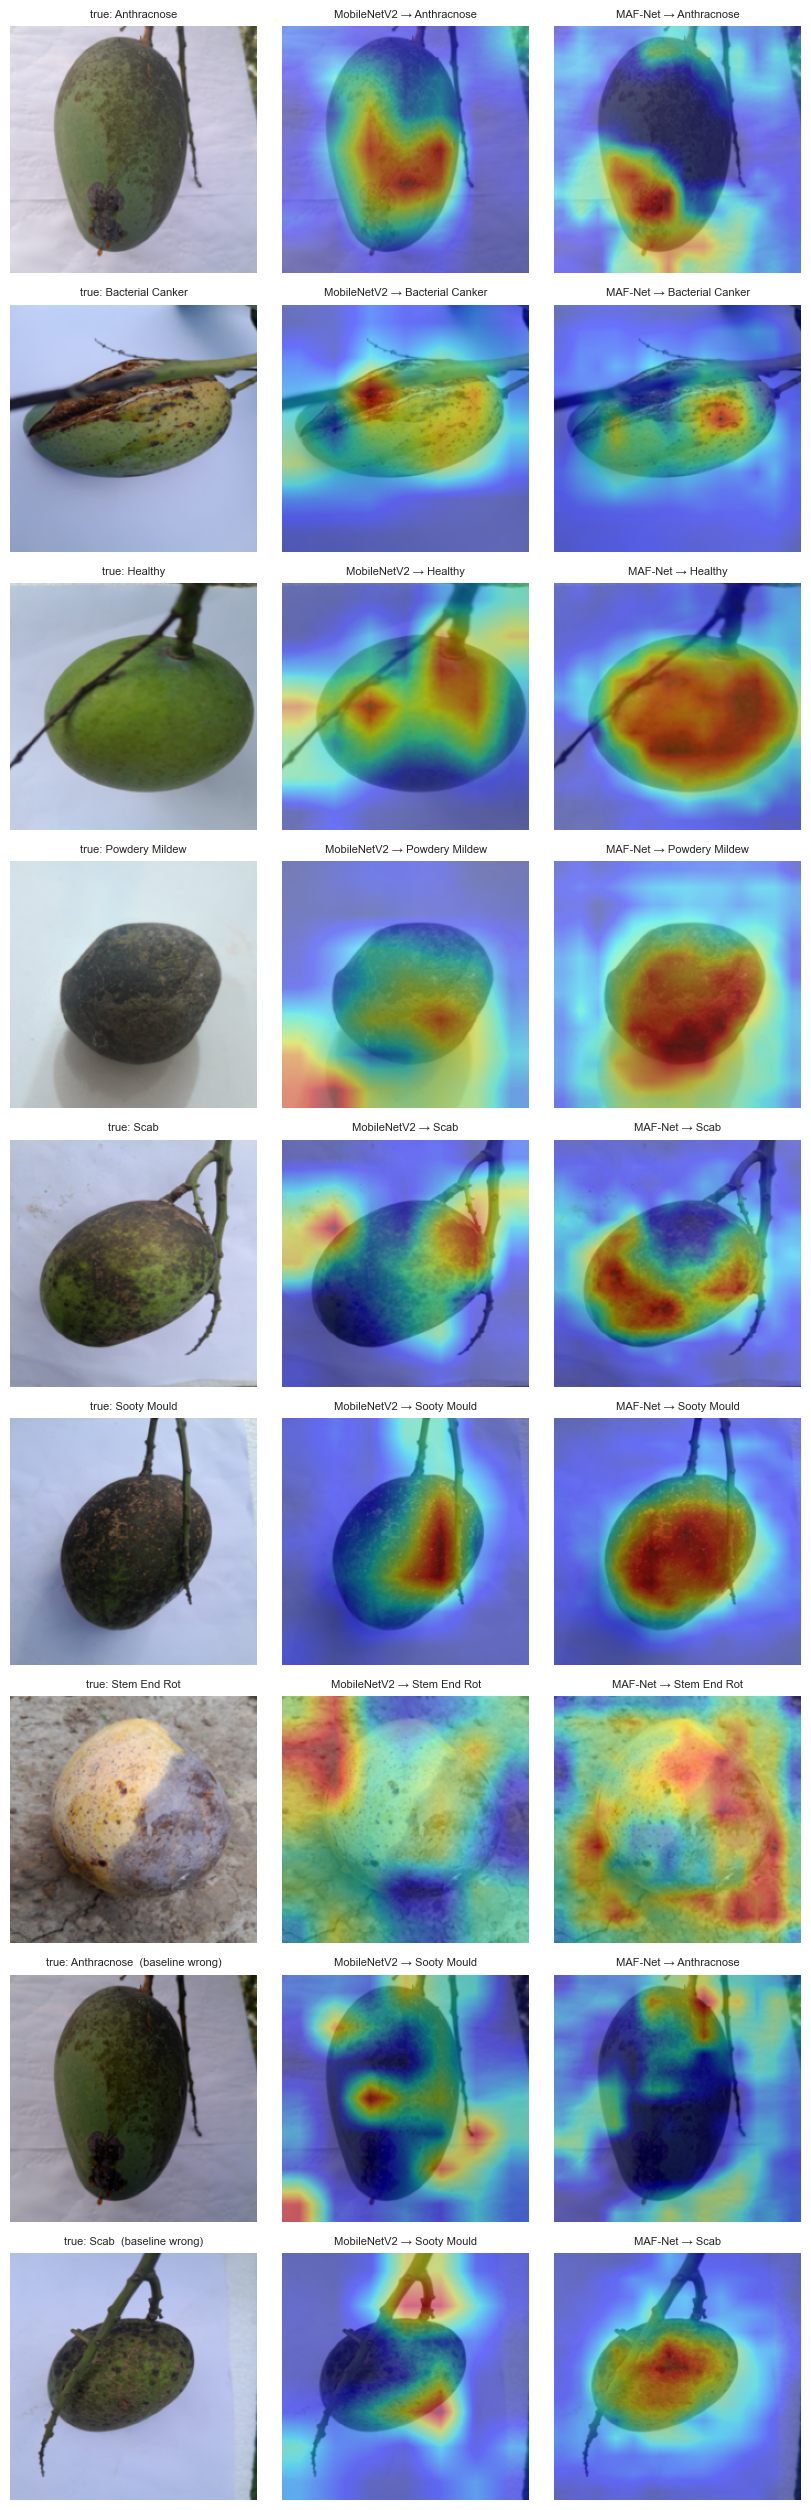

In [19]:
sp0 = SPLITS[0]
xai_prop = build_mafnet(pretrained=False).to(DEVICE)
xai_prop.load_state_dict(torch.load(os.path.join(W_DIR, f"{safe(PROPOSED)}_r0_f0.pt"), map_location=DEVICE))
xai_base = build_baseline("MobileNetV2", pretrained=False).to(DEVICE)
xai_base.load_state_dict(torch.load(os.path.join(W_DIR, "MobileNetV2_r0_f0.pt"), map_location=DEVICE))
xai_prop.eval(); xai_base.eval()

class GradCAM:
    def __init__(self, model, layer):
        self.model, self.acts = model, None
        self.h = layer.register_forward_hook(lambda m, i, o: setattr(self, "acts", o))
    def __call__(self, x, cls=None):
        with torch.enable_grad():
            out = self.model(x)
            cls = out.argmax(1) if cls is None else cls
            g = torch.autograd.grad(out.gather(1, cls.view(-1, 1)).sum(), self.acts)[0]
        cam = F.relu((g.mean((2, 3), keepdim=True) * self.acts).sum(1, keepdim=True))
        cam = F.interpolate(cam, size=x.shape[-2:], mode="bilinear", align_corners=False)[:, 0]
        cam = cam - cam.amin((1, 2), keepdim=True)
        return (cam / (cam.amax((1, 2), keepdim=True) + 1e-8)).detach(), out.detach()
    def remove(self): self.h.remove()

cam_prop = GradCAM(xai_prop, xai_prop.net.ca if xai_prop.net.use_ca else xai_prop.net.msf)
cam_base = GradCAM(xai_base, xai_base.net.bn2)

def x_of(j): return eval_preprocess(load_batch([j]))

te = sp0["test"]
pred_p = oof_pred[PROPOSED][0][te]; pred_b = oof_pred["MobileNetV2"][0][te]; yt = LABELS[te]
pick = [te[np.where((yt == c) & (pred_p == c))[0][0]] for c in range(NUM_CLASSES) if np.any((yt == c) & (pred_p == c))]
fixed = te[np.where((pred_p == yt) & (pred_b != yt))[0]][:3].tolist()     # cases the baseline got wrong
sel = (pick + fixed) or te[:4].tolist()
if not pick: pick = te[:4].tolist()
fig, axes = plt.subplots(len(sel), 3, figsize=(8.4, 2.8 * len(sel)))
axes = np.atleast_2d(axes)
for r_, j in enumerate(sel):
    x = x_of(j); img = x[0].permute(1, 2, 0).cpu().numpy()
    cb, ob = cam_base(x); cp, op = cam_prop(x)
    axes[r_, 0].imshow(img); axes[r_, 0].set_title(f"true: {CLASSES[LABELS[j]]}" + ("  (baseline wrong)" if j in fixed else ""), fontsize=8)
    axes[r_, 1].imshow(img); axes[r_, 1].imshow(cb[0].cpu(), cmap="jet", alpha=0.45)
    axes[r_, 1].set_title(f"MobileNetV2 → {CLASSES[ob.argmax(1).item()]}", fontsize=8)
    axes[r_, 2].imshow(img); axes[r_, 2].imshow(cp[0].cpu(), cmap="jet", alpha=0.45)
    axes[r_, 2].set_title(f"MAF-Net → {CLASSES[op.argmax(1).item()]}", fontsize=8)
    for a in axes[r_]: a.axis("off")
plt.tight_layout(); savefig("gradcam_comparison"); plt.show()

In [20]:
@torch.no_grad()
def _probs(model, xs, cls):
    return F.softmax(model(xs).float(), 1)[:, cls].cpu().numpy()

def deletion_auc(model, cam, j, steps=10, random_map=False, rng=None):
    x = x_of(j)
    sal, out = cam(x); cls = out.argmax(1).item()
    sal = sal[0].flatten()
    if random_map:
        sal = torch.from_numpy(rng.random(sal.numel()).astype(np.float32)).to(DEVICE)
    order = torch.argsort(sal, descending=True)
    blur = F.avg_pool2d(x, 31, stride=1, padding=15, count_include_pad=False)
    H, W = x.shape[-2:]; xs = []
    for s in range(steps + 1):
        m = torch.zeros(H * W, device=DEVICE); m[order[: int(s / steps * H * W)]] = 1
        m = m.view(1, 1, H, W); xs.append(x * (1 - m) + blur * m)
    p = _probs(model, torch.cat(xs), cls)
    return float(_trapz(p, dx=1 / steps))

_trapz = getattr(np, "trapezoid", None) or np.trapz   # NumPy 2.x renamed trapz

rng = np.random.default_rng(SEED)
del_idx = te[:XAI_N_DELETION]
res_del = {"MAF-Net Grad-CAM": [], "MAF-Net random": [], "MobileNetV2 Grad-CAM": [], "MobileNetV2 random": []}
for j in del_idx:
    res_del["MAF-Net Grad-CAM"].append(deletion_auc(xai_prop, cam_prop, j))
    res_del["MAF-Net random"].append(deletion_auc(xai_prop, cam_prop, j, random_map=True, rng=rng))
    res_del["MobileNetV2 Grad-CAM"].append(deletion_auc(xai_base, cam_base, j))
    res_del["MobileNetV2 random"].append(deletion_auc(xai_base, cam_base, j, random_map=True, rng=rng))
DEL = pd.DataFrame({k: {"deletion AUC (lower=better)": np.mean(v), "std": np.std(v, ddof=1)} for k, v in res_del.items()}).T
p_del = wilcoxon_p(np.array(res_del["MAF-Net Grad-CAM"]), np.array(res_del["MAF-Net random"]))
print(f"Deletion test on {len(del_idx)} test images. MAF-Net Grad-CAM vs random: Wilcoxon p = {p_del:.3g}")
DEL.to_csv(os.path.join(TAB_DIR, "xai_deletion_auc.csv"))
DEL

Deletion test on 100 test images. MAF-Net Grad-CAM vs random: Wilcoxon p = 0.000782


,deletion AUC (lower=better),std
MAF-Net Grad-CAM,0.4742,0.1884
MAF-Net random,0.4214,0.1175
MobileNetV2 Grad-CAM,0.5989,0.181
MobileNetV2 random,0.4116,0.1121


  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

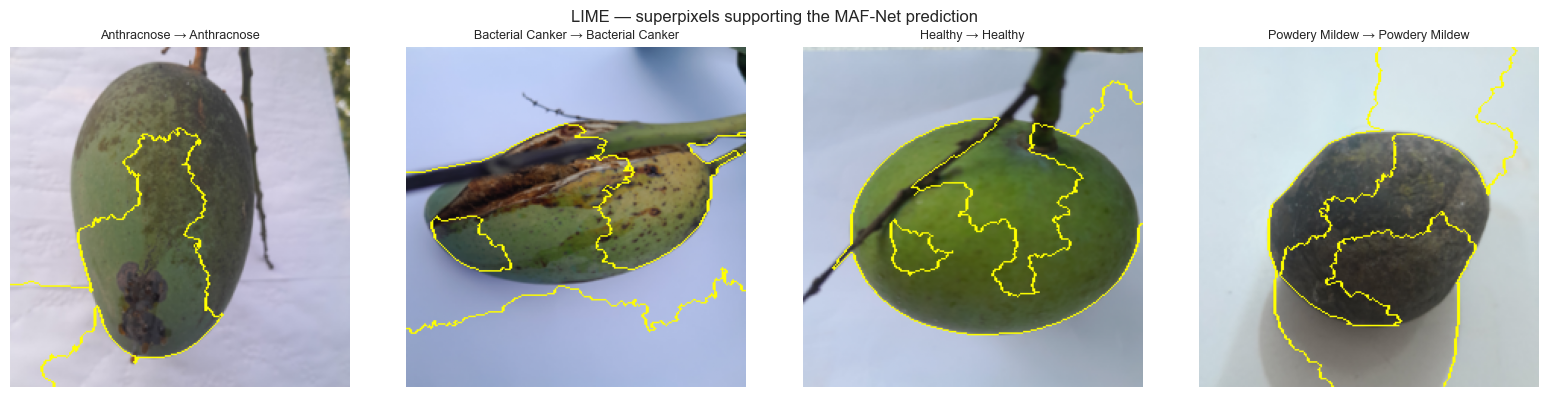

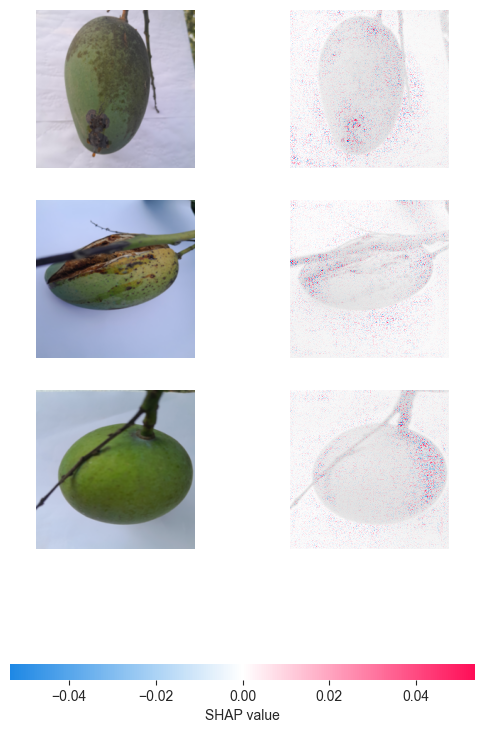

In [21]:
# ---------------- LIME ----------------
if RUN_LIME:
    try:
        from lime import lime_image
        from skimage.segmentation import mark_boundaries
        def lime_predict(batch):
            x = torch.from_numpy(np.stack(batch)).permute(0, 3, 1, 2).float().div(255).to(DEVICE)
            with torch.no_grad():
                return F.softmax(xai_prop(x).float(), 1).cpu().numpy()
        explainer = lime_image.LimeImageExplainer(random_state=SEED)
        n_l = min(4, len(pick))
        fig, axes = plt.subplots(1, n_l, figsize=(4 * n_l, 4)); axes = np.atleast_1d(axes)
        for a, j in zip(axes, pick[:n_l]):
            arr = (x_of(j)[0].permute(1, 2, 0).cpu().numpy() * 255).round().astype(np.uint8)
            exp = explainer.explain_instance(arr, lime_predict, top_labels=1, hide_color=0,
                                             num_samples=1000 if not FAST_MODE else 50, batch_size=50)
            lbl = exp.top_labels[0]
            tmp, mask = exp.get_image_and_mask(lbl, positive_only=True, num_features=6, hide_rest=False)
            a.imshow(mark_boundaries(tmp / 255.0, mask)); a.axis("off")
            a.set_title(f"{CLASSES[LABELS[j]]} → {CLASSES[lbl]}", fontsize=9)
        plt.suptitle("LIME — superpixels supporting the MAF-Net prediction")
        plt.tight_layout(); savefig("lime"); plt.show()
    except Exception as e:
        print("LIME skipped:", type(e).__name__, e)

# ---------------- SHAP ----------------
if RUN_SHAP:
    try:
        import shap
        torch.manual_seed(SEED)
        bg = torch.cat([x_of(j) for j in sp0["train"][:: max(1, len(sp0["train"]) // 16)][:16]])
        smp = torch.cat([x_of(j) for j in pick[:3]])
        explainer = shap.GradientExplainer(xai_prop, bg)
        sv, ind = explainer.shap_values(smp, ranked_outputs=1, nsamples=50 if FAST_MODE else 200)
        sv = sv if isinstance(sv, list) else [sv[..., 0]] if np.ndim(sv) == 5 else [sv]
        sv_np = [np.transpose(np.asarray(s), (0, 2, 3, 1)) for s in sv]
        shap.image_plot(sv_np, smp.permute(0, 2, 3, 1).cpu().numpy(), show=False)
        savefig("shap"); plt.show()
    except Exception as e:
        print("SHAP skipped:", type(e).__name__, e)

cam_prop.remove(); cam_base.remove()
del xai_prop, xai_base; cleanup()

## 18. Claims check — what you can honestly write in the paper
Every line is computed from the results above. Only state a claim in the paper if its line shows **PASS**. If something fails, the line says what to write instead.

In [22]:
def line(ok, text, alt=""):
    print(("PASS  " if ok else "FAIL  ") + text + ("" if ok else f"\n      -> {alt}"))
    return ok

base_names = list(BASELINES)
rank_acc = list(MAIN.index).index(PROPOSED) + 1
best_f1 = MAIN["_f1"].idxmax()
checks = {}
print("=" * 78); print(f"{'CLAIMS CHECK':^78}"); print("=" * 78)
checks["top_acc"] = line(rank_acc == 1, f"Highest mean accuracy ({100*MAIN.loc[PROPOSED,'_acc']:.2f}%, rank {rank_acc}/{len(MAIN)})",
                         f"best is {MAIN.index[0]} ({100*MAIN['_acc'].iloc[0]:.2f}%). Frame MAF-Net as the best accuracy-efficiency trade-off.")
checks["top_f1"] = line(best_f1 == PROPOSED, "Highest mean macro-F1", f"best is {best_f1}")
sig_t = (SIG["p corr-t (Holm)"] < 0.05) & (SIG["Δacc (pp)"] > 0)
sig_m = (SIG["p McNemar (Holm)"] < 0.05) & (SIG["Δacc (pp)"] > 0)
checks["sig_t"] = line(bool(sig_t.all()), f"Significantly better than ALL baselines (corrected t, Holm): {int(sig_t.sum())}/{len(SIG)}",
                       f"significant only vs: {list(SIG.index[sig_t])}. Report 'comparable to' for the rest.")
checks["sig_m"] = line(bool(sig_m.all()), f"Significantly better than ALL baselines (McNemar, Holm): {int(sig_m.sum())}/{len(SIG)}",
                       f"significant only vs: {list(SIG.index[sig_m])}")
if RUN_ABLATION:
    m_ = lambda n: fold_acc(n).mean()
    cum = [m_("MobileNetV2"), m_("MobileNetV2 + MSF"), m_("MobileNetV2 + MSF + CA"), m_(PROPOSED)]
    checks["abl_cum"] = line(all(b > a for a, b in zip(cum, cum[1:])),
                             "Ablation is monotonic: backbone < +MSF < +MSF+CA < +KD (full)",
                             f"means = {[round(100*float(c), 2) for c in cum]}. Discuss the component that does not help, or drop it.")
    loo = {k: m_(k) for k in ["MAF-Net w/o MSF", "MAF-Net w/o CA", "MobileNetV2 + MSF + CA"]}
    checks["abl_loo"] = line(all(v < m_(PROPOSED) for v in loo.values()),
                             "Removing ANY single component lowers accuracy (leave-one-out)",
                             f"{ {k: round(100*float(v), 2) for k, v in loo.items()} } vs full {100*m_(PROPOSED):.2f}")
light = EFF.loc[base_names + [PROPOSED]]
others = [b for b in base_names if b != "MobileNetV2"]
checks["lighter"] = line(all(EFF.loc[PROPOSED, "params_M"] < EFF.loc[b, "params_M"] for b in others),
                         f"Fewer parameters than every baseline except its own MobileNetV2 backbone "
                         f"({EFF.loc[PROPOSED,'params_M']:.2f} M = backbone + {EFF.loc[PROPOSED,'params_M']-EFF.loc['MobileNetV2','params_M']:.2f} M)",
                         f"smaller baseline(s): {[b for b in others if EFF.loc[b,'params_M'] <= EFF.loc[PROPOSED,'params_M']]}")
heavy = [b for b in base_names if EFF.loc[b, "params_M"] > 10]
if heavy:
    ratio = min(EFF.loc[h, "params_M"] for h in heavy) / EFF.loc[PROPOSED, "params_M"]
    checks["vs_heavy"] = line(all(MAIN.loc[PROPOSED, "_acc"] >= MAIN.loc[h, "_acc"] for h in heavy),
                              f"Matches or beats every heavy (>10 M) model with {ratio:.0f}x+ fewer parameters",
                              "a heavy model is more accurate. Report the accuracy-per-parameter trade-off.")
rk = lambda col: light[col].rank(method="min").loc[PROPOSED]
print(f"INFO  GMACs rank {rk('GMACs'):.0f}/{len(light)} | CPU-latency rank {rk('cpu_ms'):.0f}/{len(light)} "
      f"| GPU-latency rank {rk('gpu_ms'):.0f}/{len(light)}  (1 = cheapest; report as measured)")
print("=" * 78)

summary = {"proposed": PROPOSED, "folds": len(SPLITS), "dedup_method": method, "dedup_threshold": thr,
           "groups": int(len(np.unique(GROUPS))), "mean_acc": float(MAIN.loc[PROPOSED, "_acc"]),
           "std_acc": float(fold_acc(PROPOSED).std(ddof=1)), "params_M": float(EFF.loc[PROPOSED, "params_M"]),
           "GMACs": float(EFF.loc[PROPOSED, "GMACs"]), "checks": {k: bool(v) for k, v in checks.items()},
           "friedman_p": float(fr_p), "nemenyi_cd": float(CD)}
json.dump(summary, open(os.path.join(RESULTS_DIR, "final_summary.json"), "w"), indent=2)

                                 CLAIMS CHECK                                 
FAIL  Highest mean accuracy (94.87%, rank 5/11)
      -> best is MobileViT-S (95.10%). Frame MAF-Net as the best accuracy-efficiency trade-off.
FAIL  Highest mean macro-F1
      -> best is MobileViT-S
FAIL  Significantly better than ALL baselines (corrected t, Holm): 0/10
      -> significant only vs: []. Report 'comparable to' for the rest.
FAIL  Significantly better than ALL baselines (McNemar, Holm): 0/10
      -> significant only vs: []
FAIL  Ablation is monotonic: backbone < +MSF < +MSF+CA < +KD (full)
      -> means = [94.39, 94.83, 94.81, 94.87]. Discuss the component that does not help, or drop it.
FAIL  Removing ANY single component lowers accuracy (leave-one-out)
      -> {'MAF-Net w/o MSF': 94.85, 'MAF-Net w/o CA': 95.11, 'MobileNetV2 + MSF + CA': 94.81} vs full 94.87
PASS  Fewer parameters than every baseline except its own MobileNetV2 backbone (2.44 M = backbone + 0.20 M)
FAIL  Matches or beats 

## 19. Final deployable model (trained on all images) and export
The cross-validation models measure performance; **this** is the model you deploy or share.
* The four teachers and MAF-Net are retrained on **all** images. A group-aware 10 % hold-out is used only for early stopping and a sanity check.
* Files are saved in `results_MAFNet/deploy/`:

| File | Use |
|---|---|
| `MAF-Net_final_weights.pt` | PyTorch `state_dict` (needs the model class from this notebook) |
| `MAF-Net_final_checkpoint.pt` | weights + class names + image size + training info |
| `MAF-Net_final_torchscript.pt` | **stand-alone** model, loads with `torch.jit.load`, no model code needed |
| `MAF-Net_final.onnx` | ONNX for ONNX Runtime / mobile / edge (exported when the `onnx` package is installed) |
| `model_config.json`, `predict.py` | ready-to-run inference script: `python predict.py image.jpg` |

The exported model takes an RGB image scaled to [0, 1] at 224×224 and does its own ImageNet normalisation.

In [23]:
DEPLOY_DIR = os.path.join(RESULTS_DIR, "deploy"); os.makedirs(DEPLOY_DIR, exist_ok=True)
final_ckpt = os.path.join(DEPLOY_DIR, "MAF-Net_final_checkpoint.pt")

if TRAIN_FINAL_MODEL and not os.path.exists(final_ckpt):
    hold = StratifiedGroupKFold(n_splits=10, shuffle=True, random_state=SEED + 999)
    tr_i, va_i = next(hold.split(np.zeros(N), LABELS, GROUPS))
    FINAL = {"r": "final", "f": 0, "train": np.sort(tr_i), "val": np.sort(va_i), "test": np.sort(va_i)}
    print(f"Final training: {len(tr_i)} train images, {len(va_i)} hold-out images (early stopping only)")

    teacher = np.zeros((N, NUM_CLASSES), np.float32)
    for t in TEACHERS:
        f_t = os.path.join(DEPLOY_DIR, f"teacher_logits_{safe(t)}.npy")
        if not os.path.exists(f_t):
            seed_everything(SEED + 7); t0 = time.time()
            m, _, _ = train_model(build_baseline(t), FINAL, SEED + 7, tag="final-" + t)
            np.save(f_t, (predict_logits(m, FINAL["train"]) + predict_logits(m, FINAL["train"], hflip=True)) / 2)
            print(f"  teacher {t:12s} done in {(time.time()-t0)/60:.1f} min"); del m; cleanup()
        teacher[FINAL["train"]] += np.load(f_t) / len(TEACHERS)

    seed_everything(SEED + 7); t0 = time.time()
    final_model, fhist, fep = train_model(build_mafnet(), FINAL, SEED + 7, teacher_logits=teacher, tag="final-MAF-Net")
    hold_acc = float((predict_logits(final_model, FINAL["val"]).argmax(1) == LABELS[FINAL["val"]]).mean())
    torch.save({"state_dict": {k: v.detach().cpu() for k, v in final_model.state_dict().items()},
                "classes": CLASSES, "img_size": IMG_SIZE, "cache_size": CACHE_SIZE,
                "arch": {"backbone": "mobilenetv2_100", "msf": True, "ca": True, "fusion_dim": FUSION_DIM,
                         "ca_reduction": CA_REDUCTION, "drop_rate": DROP_RATE},
                "holdout_acc": hold_acc, "best_epoch": int(fep), "cv_mean_acc": float(MAIN.loc[PROPOSED, "_acc"]),
                "environment": {k: str(v) for k, v in env_info.items()}}, final_ckpt)
    print(f"Final MAF-Net trained in {(time.time()-t0)/60:.1f} min | hold-out acc {hold_acc:.4f} | best epoch {fep}")
    del final_model; cleanup()
elif os.path.exists(final_ckpt):
    print("Final checkpoint already exists:", final_ckpt)
else:
    print("TRAIN_FINAL_MODEL is False -> skipped.")

Final training: 3151 train images, 349 hold-out images (early stopping only)
  teacher ResNet50     done in 2.6 min
  teacher DenseNet121  done in 4.1 min
  teacher InceptionV3  done in 2.4 min
  teacher Xception     done in 2.6 min
Final MAF-Net trained in 2.2 min | hold-out acc 0.9427 | best epoch 20


In [24]:
# ---------------- export: weights .pt, TorchScript .pt, ONNX, predict.py ----------------
PREDICT_PY = '''# MAF-Net inference.  Usage:  python predict.py image1.jpg [image2.jpg ...]
# Needs only: torch, numpy, pillow  (no timm, no notebook code).
import os, sys, json
import numpy as np
import torch
import torch.nn.functional as F
from PIL import Image, ImageOps

HERE = os.path.dirname(os.path.abspath(__file__))
CFG = json.load(open(os.path.join(HERE, "model_config.json")))
MODEL = torch.jit.load(os.path.join(HERE, "MAF-Net_final_torchscript.pt"), map_location="cpu").eval()

def preprocess(path):
    s = CFG["cache_size"]
    with Image.open(path) as im:
        im.draft("RGB", (s * 2, s * 2))
        im = ImageOps.exif_transpose(im).convert("RGB").resize((s, s), Image.BICUBIC, reducing_gap=2.0)
    x = torch.from_numpy(np.asarray(im, dtype=np.uint8).copy()).permute(2, 0, 1)[None].float() / 255
    return F.interpolate(x, size=(CFG["img_size"], CFG["img_size"]), mode="bilinear",
                         align_corners=False, antialias=True)

@torch.no_grad()
def predict(path, top_k=3):
    p = F.softmax(MODEL(preprocess(path)), dim=1)[0]
    conf, idx = p.topk(min(top_k, len(CFG["classes"])))
    return [(CFG["classes"][i], float(c)) for c, i in zip(conf, idx)]

if __name__ == "__main__":
    for path in sys.argv[1:]:
        res = predict(path)
        print(os.path.basename(path) + ": " + res[0][0] + " (%.1f%%)   top-3: " % (100 * res[0][1])
              + ", ".join("%s %.1f%%" % (c, 100 * v) for c, v in res))
'''

if os.path.exists(final_ckpt):
    ck = torch.load(final_ckpt, map_location="cpu", weights_only=True)
    deploy_model = build_mafnet(pretrained=False)
    deploy_model.load_state_dict(ck["state_dict"])
    deploy_model = deploy_model.eval().float().cpu()

    torch.save(deploy_model.state_dict(), os.path.join(DEPLOY_DIR, "MAF-Net_final_weights.pt"))

    example = torch.rand(1, 3, IMG_SIZE, IMG_SIZE)
    ts_path = os.path.join(DEPLOY_DIR, "MAF-Net_final_torchscript.pt")
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        with torch.no_grad():
            ts = torch.jit.trace(deploy_model, example)
        ts.save(ts_path)
        ts_loaded = torch.jit.load(ts_path, map_location="cpu").eval()
    check = eval_preprocess(load_batch(np.arange(min(8, N)))).float().cpu()
    with torch.no_grad():
        diff = (ts_loaded(check) - deploy_model(check)).abs().max().item()
    print(f"TorchScript saved and verified (max |difference| = {diff:.2e})")

    onnx_path = os.path.join(DEPLOY_DIR, "MAF-Net_final.onnx")
    try:
        import onnx  # noqa: F401
        kw = dict(input_names=["image"], output_names=["logits"], opset_version=17,
                  dynamic_axes={"image": {0: "batch"}, "logits": {0: "batch"}})
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            try:
                torch.onnx.export(deploy_model, example, onnx_path, dynamo=False, **kw)
            except TypeError:
                torch.onnx.export(deploy_model, example, onnx_path, **kw)
        print("ONNX saved:", onnx_path)
        try:
            import onnxruntime as ort
            sess = ort.InferenceSession(onnx_path, providers=["CPUExecutionProvider"])
            o = sess.run(None, {"image": check.numpy()})[0]
            with torch.no_grad():
                ref = deploy_model(check).numpy()
            print(f"ONNX Runtime verified (max |difference| = {np.abs(o - ref).max():.2e})")
        except ImportError:
            print("(install onnxruntime to verify the ONNX file)")
    except ImportError:
        print("ONNX export skipped: run  pip install onnx onnxruntime  and re-run this cell.")
    except Exception as e:
        print("ONNX export skipped:", type(e).__name__, e)

    json.dump({"classes": CLASSES, "img_size": IMG_SIZE, "cache_size": CACHE_SIZE,
               "input": "RGB float32 in [0,1], shape [B,3,224,224]; normalisation is inside the model",
               "holdout_acc": ck["holdout_acc"], "cv_mean_acc": ck["cv_mean_acc"],
               "params_M": count_params(deploy_model)},
              open(os.path.join(DEPLOY_DIR, "model_config.json"), "w"), indent=2)
    with open(os.path.join(DEPLOY_DIR, "predict.py"), "w", encoding="utf-8") as fh:
        fh.write(PREDICT_PY)

    import subprocess, sys
    out = subprocess.run([sys.executable, os.path.join(DEPLOY_DIR, "predict.py")] + list(meta["path"].iloc[:2]),
                         capture_output=True, text=True)
    print("predict.py test:\n" + (out.stdout or out.stderr)[-800:])

    print("Deployment files:")
    for f in sorted(os.listdir(DEPLOY_DIR)):
        if not f.startswith("teacher_logits"):
            print(f"  {f:34s} {os.path.getsize(os.path.join(DEPLOY_DIR, f))/1e6:7.2f} MB")
    del deploy_model, ts, ts_loaded; cleanup()

TorchScript saved and verified (max |difference| = 0.00e+00)
ONNX saved: d:\Research Works\Arpon\Mango\results_MAFNet\deploy\MAF-Net_final.onnx
ONNX Runtime verified (max |difference| = 1.79e-06)
predict.py test:
Anthracnose_001.jpg: Anthracnose (93.7%)   top-3: Anthracnose 93.7%, Scab 1.1%, Sooty Mould 1.1%
Anthracnose_002.jpg: Anthracnose (91.6%)   top-3: Anthracnose 91.6%, Bacterial Canker 1.5%, Scab 1.5%

Deployment files:
  MAF-Net_final.onnx                    9.73 MB
  MAF-Net_final_checkpoint.pt          10.01 MB
  MAF-Net_final_torchscript.pt         10.49 MB
  MAF-Net_final_weights.pt             10.03 MB
  model_config.json                     0.00 MB
  predict.py                            0.00 MB


In [25]:
# ---- export paper tables (CSV always; Excel + LaTeX if available) ----
tables = {"main_comparison": MAIN.drop(columns=["_acc", "_f1"]), "significance": SIG,
          "ablation": ABL.drop(columns=["_mean", "_std"]), "efficiency": EFF.round(3),
          "per_class_f1": PC.round(4), "per_fold": FOLD, "xai_deletion": DEL}
try:
    with pd.ExcelWriter(os.path.join(TAB_DIR, "paper_tables.xlsx")) as xw:
        for k, v in tables.items(): v.to_excel(xw, sheet_name=k[:31])
    print("Excel tables written.")
except Exception as e:
    print("Excel export skipped:", e)
try:
    with open(os.path.join(TAB_DIR, "paper_tables.tex"), "w", encoding="utf-8") as fh:
        for k in ["main_comparison", "significance", "ablation"]:
            fh.write(f"% ---- {k} ----\n" + tables[k].to_latex(escape=True, float_format="%.4g") + "\n\n")
    print("LaTeX tables written.")
except Exception as e:
    print("LaTeX export skipped:", e)

print("\nSaved files:")
for root, _, files in os.walk(RESULTS_DIR):
    if os.path.basename(root) == "runs": print("  runs/ :", len(files), "run files"); continue
    for f in sorted(files):
        if not f.startswith("image_cache"):
            print("  ", os.path.relpath(os.path.join(root, f), RESULTS_DIR))
print("\nDone.")

Excel tables written.
LaTeX tables written.

Saved files:
   dataset_index_with_groups.csv
   environment.json
   final_summary.json
   splits.json
   deploy\MAF-Net_final.onnx
   deploy\MAF-Net_final_checkpoint.pt
   deploy\MAF-Net_final_torchscript.pt
   deploy\MAF-Net_final_weights.pt
   deploy\model_config.json
   deploy\predict.py
   deploy\teacher_logits_DenseNet121.npy
   deploy\teacher_logits_InceptionV3.npy
   deploy\teacher_logits_ResNet50.npy
   deploy\teacher_logits_Xception.npy
   figures\ablation.pdf
   figures\ablation.png
   figures\accuracy_vs_cost.pdf
   figures\accuracy_vs_cost.png
   figures\augmentation_examples.pdf
   figures\augmentation_examples.png
   figures\class_distribution.pdf
   figures\class_distribution.png
   figures\confusion_matrices.pdf
   figures\confusion_matrices.png
   figures\duplicate_similarity_hist.pdf
   figures\duplicate_similarity_hist.png
   figures\friedman_nemenyi_cd.pdf
   figures\friedman_nemenyi_cd.png
   figures\gradcam_comparison.